# 토크나이저에서 검색기까지

이 노트북에서는 텍스트를 받아 관련 문서를 반환하는 작은 검색기를 만든다. 문자열을 자르는 규칙부터 시작해서, 토큰을 문맥에 따라 변환하고, 문장 하나를 벡터 하나로 표현한 뒤, 정답 문서를 더 높은 순위에 놓도록 학습시킨다. 앞에서 만든 토크나이저를 마지막 검색에서도 그대로 사용한다.

코드는 위에서 아래로 실행하면 된다. 구현은 모두 이 파일 안에 있다. 외부의 `lab.py`나 완성된 모델 클래스를 불러오지 않는다. PyTorch의 텐서·선형층·자동 미분·optimizer는 사용하며, BPE와 attention, masking, pooling, 학습 loop는 직접 작성한다. 여기서 ‘직접 구현’의 경계는 행렬곱과 자동 미분을 다시 만드는 데 있지 않고, 모델이 수행할 계산을 직접 정의하는 데 있다.

선형대수의 행렬곱, 확률의 조건부 확률, 미분의 연쇄법칙, 경사하강법을 한 번 배운 독자를 가정한다. Transformer를 써 본 경험은 필요하지 않다. `reshape`, `transpose`, broadcasting이 등장할 때는 실제 shape를 함께 확인한다.

한 번에 읽어도 되지만, 수업에서는 다음 구간을 나누어 진행할 수 있다. 소요 시간은 코드를 수정하는 정도에 따라 달라진다.

| 구간 | 수업 중 만드는 것 | 손으로 설명할 수 있어야 하는 내용 |
|---|---|---|
| 1장 | BPE 토크나이저, 배치 입력 | 한 merge가 선택되는 이유와 새 단어가 ID로 바뀌는 과정 |
| 2장 | 임베딩층, attention, encoder | 각 텐서의 축과 mask가 적용되는 위치 |
| 3–4장 | MLM 학습, 문장 벡터 | 언어 모델의 목적과 검색 점수의 차이 |
| 5–6장 | 검색 학습, 평가, 저장과 복원 | 관련성 label이 파라미터와 검색 순위를 바꾸는 경로 |
| 7장 | 설계 변경 과제와 해설 | 새 데이터의 조건에 맞춰 구조와 loss를 바꾸는 방법 |

첫 실행은 설정을 바꾸지 않고 진행한다. 계산 결과를 확인한 뒤 옆의 짧은 문제를 풀고, 두 번째 실행에서 한 가지 조건을 바꾼다. 완성 코드가 들어 있으므로 `Run All`도 가능하다. 문제의 해설은 같은 파일 안에 있으며, 필수 실행 경로에는 빈칸이나 `TODO`가 없다.

설정을 바꾼 실험은 기본적으로 **Restart Kernel and Run All**로 시작한다. 노트북 변수에는 앞선 실행의 학습 결과가 남아 있다. 이미 학습한 모델에 학습 loop만 다시 실행하면 초기값 비교가 아니라 추가 학습이 된다. `backward()`가 사용한 계산 그래프도 보통 한 번 소비되므로, loss 셀만 반복하기보다 그 입력의 forward부터 다시 실행해야 한다.

| 바꾼 항목 | 다시 만들어야 할 것 |
|---|---|
| 토크나이저의 정규화·merge 예산 | 전체 ID와 모든 모델. 전체 재시작이 가장 확실하다. |
| encoder 차원·head·층 수 | 모델 생성부터 MLM과 검색 학습까지 |
| 검색 loss·학습률·temperature | 같은 초기 모델의 새 복사본과 새 optimizer부터 |
| 마지막 검색 질의 문자열 | 검색 셀만 재실행 |

## 실행 환경

저장소의 `260921SearchStudy/README.md`에 있는 설치 명령으로 Python 환경과 패키지를 준비한다. 그 뒤 터미널에서 이 노트북이 있는 `260921SearchStudy` 폴더로 이동해 다음 명령으로 연다.

```bash
source .venv/bin/activate
jupyter lab Dense_Retrieval_From_Scratch.ipynb
```

다른 환경에서는 Python 3.12 이상과 `torch`, `numpy`, `matplotlib`, `jupyterlab`을 설치한다. GPU는 필요하지 않다. 데이터를 다운로드하거나 API 키를 입력하는 단계도 없다. CPU 시간은 마지막에 출력되며, 하드웨어에 따라 달라진다. 아래 `sys.executable`이 방금 활성화한 환경을 가리키는지 먼저 확인한다.

In [1]:
import sys
import math
import random
import json
import re
import unicodedata
import copy
import time
import hashlib
import html
from pathlib import Path
from collections import Counter
from dataclasses import dataclass, asdict

import numpy as np
import torch
from torch import nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
from IPython.display import display, HTML, Markdown

torch.set_num_threads(1)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
STARTED_AT = time.perf_counter()
ARTIFACT_DIR = Path.cwd() / "artifacts" / "course"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("계산 장치: CPU")

def show_table(headers, rows):
    """노트북의 작은 표를 표시한다. 모델 계산에는 관여하지 않는다."""
    def cell(value):
        return html.escape(str(value))
    heading = "".join(f"<th>{cell(x)}</th>" for x in headers)
    body = "".join("<tr>" + "".join(f"<td>{cell(x)}</td>" for x in row) + "</tr>" for row in rows)
    display(HTML(f"<table><thead><tr>{heading}</tr></thead><tbody>{body}</tbody></table>"))

Python: /home/baemo_pc/260821/dense-retrieval-lab/.venv/bin/python
PyTorch: 2.14.0+cpu
계산 장치: CPU


## 우리가 풀 검색 문제

검색 대상은 12개 문서다. 앞의 여섯 문서는 관계의 방향을 확인하기 위해 만든 최소쌍이다. 예를 들어 `고양이 가 쥐 를 쫓다`와 `쥐 가 고양이 를 쫓다`는 단어와 빈도가 같지만 누가 누구를 쫓는지는 다르다. 조사까지 띄어 쓴 것은 이 조건을 정확하게 만들기 위해서다. 나머지 문서는 암호 재설정, 환불 기간, 배송 위치처럼 작은 안내 검색 문제를 표현한다.

데이터를 실제 서비스 로그처럼 읽으면 안 된다. 이 자료는 계산을 추적하고 구조의 한계를 드러내기 위해 만든 것이다. 대신 코드의 데이터 계약은 실무와 같다. `DOCS[j]`는 검색할 문서이고, `(query, j)`는 그 질의의 정답 문서다. 질의당 정답 하나라는 조건은 loss와 평가를 작성할 때 다시 사용한다.

아래의 데이터도 노트북에 들어 있다. 파일 경로나 네트워크 상태에 따라 수업이 달라지지 않도록 하기 위해서다.

In [2]:
DOC_NAMES: list[str] = [
    "고양이가 쥐를 쫓음",
    "쥐가 고양이를 쫓음",
    "개가 토끼를 도움",
    "토끼가 개를 도움",
    "교사가 제자를 가르침",
    "제자가 교사를 가르침",
    "비밀번호 초기화",
    "환불 입금 소요 기간",
    "택배 위치 조회",
    "카드 결제 실패",
    "진료 예약 취소",
    "반려묘 먹이 선택",
]

DOCS: list[str] = [
    "고양이 가 쥐 를 쫓다",
    "쥐 가 고양이 를 쫓다",
    "개 가 토끼 를 돕다",
    "토끼 가 개 를 돕다",
    "교사 가 제자 를 가르치다",
    "제자 가 교사 를 가르치다",
    "계정 비밀번호 초기화 안내",
    "환불 처리 이후 입금 소요 기간",
    "택배 현재 위치 조회 안내",
    "카드 결제 실패 원인 해결",
    "진료 예약 취소 방법",
    "반려묘 사료 선택 안내",
]

# 0/1, 2/3, 4/5는 순서를 제외하면 완전히 같은 토큰과 토큰 수를 갖는다.
# 따라서 위치 정보를 사용하지 않는 토큰 임베딩의 평균으로는 구별 불가.
ORDER_PAIR: tuple[int, int] = (0, 1)
ORDER_PAIRS: tuple[tuple[int, int], ...] = ((0, 1), (2, 3), (4, 5))
PROBE_TOKEN = "추격"
SEMANTIC_PAIR: tuple[str, str] = ("추격", "쫓다")

학습 질의는 문서마다 네 개씩 둔다. `추격`과 `쫓다`처럼 다른 표현을 연결하는 예와, 주어·목적어를 뒤집었을 때 정답도 바뀌는 예가 함께 있다. 정수 label은 위 문서 목록의 인덱스다.

In [3]:
TRAIN: list[tuple[str, int]] = [
    ("고양이 가 쥐 를 추격 하다", 0),
    ("고양이 가 쥐 를 뒤쫓다", 0),
    ("고양이 가 쥐 를 쫓다 설명", 0),
    ("고양이 가 쥐 를 추격 장면", 0),
    ("쥐 가 고양이 를 추격 하다", 1),
    ("쥐 가 고양이 를 뒤쫓다", 1),
    ("쥐 가 고양이 를 쫓다 설명", 1),
    ("쥐 가 고양이 를 추격 장면", 1),
    ("개 가 토끼 를 지원 하다", 2),
    ("개 가 토끼 를 도와주다", 2),
    ("개 가 토끼 를 돕다 설명", 2),
    ("개 가 토끼 를 지원 장면", 2),
    ("토끼 가 개 를 지원 하다", 3),
    ("토끼 가 개 를 도와주다", 3),
    ("토끼 가 개 를 돕다 설명", 3),
    ("토끼 가 개 를 지원 장면", 3),
    ("교사 가 제자 를 교육 하다", 4),
    ("교사 가 제자 를 지도 하다", 4),
    ("교사 가 제자 를 가르치다 설명", 4),
    ("교사 가 제자 를 교육 장면", 4),
    ("제자 가 교사 를 교육 하다", 5),
    ("제자 가 교사 를 지도 하다", 5),
    ("제자 가 교사 를 가르치다 설명", 5),
    ("제자 가 교사 를 교육 장면", 5),
    ("로그인 암호 분실 재설정 방법", 6),
    ("잊어버린 암호 다시 설정", 6),
    ("로그인 비밀번호 잊어버린 경우", 6),
    ("계정 암호 재설정 절차", 6),
    ("돈 돌려받기 며칠 걸리나", 7),
    ("환불 완료 뒤 돈 언제 오나", 7),
    ("돌려받기 완료 뒤 며칠 기다리나", 7),
    ("입금 까지 얼마나 기다리나", 7),
    ("배송 물건 어디 왔나", 8),
    ("주문 물건 이동 경로 확인", 8),
    ("배송 중 물건 위치 확인", 8),
    ("택배 어디 있는지 확인", 8),
    ("신용카드 승인 거절 대처", 9),
    ("지불 오류 어떻게 고치나", 9),
    ("카드 승인 거절 원인", 9),
    ("지불 실패 어떻게 해결", 9),
    ("병원 방문 약속 철회 절차", 10),
    ("의사 만남 약속 없애기", 10),
    ("병원 예약 철회 방법", 10),
    ("진료 약속 없애기 절차", 10),
    ("고양이 먹이 고르기 방법", 11),
    ("냥이 밥 어떤 것 고르나", 11),
    ("반려묘 먹이 선택 방법", 11),
    ("고양이 밥 고르기 안내", 11),
]

검증 질의는 이미 나온 표현을 새로 조합한다. 아래 목록은 training loop에서 읽지 않고, 학습 전후의 순위를 비교할 때 사용한다.

In [4]:
VALID: list[tuple[str, int]] = [
    ("고양이 가 쥐 를 뒤쫓다 장면", 0),
    ("고양이 가 쥐 를 추격 하다 설명", 0),
    ("쥐 가 고양이 를 뒤쫓다 장면", 1),
    ("쥐 가 고양이 를 추격 하다 설명", 1),
    ("개 가 토끼 를 도와주다 장면", 2),
    ("개 가 토끼 를 지원 하다 설명", 2),
    ("토끼 가 개 를 도와주다 장면", 3),
    ("토끼 가 개 를 지원 하다 설명", 3),
    ("교사 가 제자 를 지도 하다 장면", 4),
    ("교사 가 제자 를 교육 하다 설명", 4),
    ("제자 가 교사 를 지도 하다 장면", 5),
    ("제자 가 교사 를 교육 하다 설명", 5),
    ("잊어버린 로그인 암호 재설정", 6),
    ("계정 비밀번호 다시 설정 방법", 6),
    ("환불 완료 뒤 며칠 기다리나", 7),
    ("돈 돌려받기 까지 얼마나 걸리나", 7),
    ("주문 물건 현재 위치 확인", 8),
    ("배송 중 물건 어디 있는지 확인", 8),
    ("신용카드 승인 거절 어떻게 해결", 9),
    ("카드 지불 오류 원인", 9),
    ("병원 진료 약속 철회 방법", 10),
    ("의사 만남 예약 없애기 절차", 10),
    ("냥이 먹이 고르기 방법", 11),
    ("반려묘 밥 어떤 것 고르나", 11),
]

# 의도적으로 어휘에 없는 표현. 실제 검색 평가가 아니라 UNK 진단용이다.
OOV_QUERY = "패스워드 리커버리"

마지막 목록은 설계를 마친 뒤 확인할 질의다. 세 목록의 문자열이 겹치지 않는지 코드로 검사한다. 노트북에서는 모든 자료를 볼 수 있지만, 수치 결과를 이용해 모델 설정을 고르는 시점을 구분해 둔다.

In [5]:
# TEST는 최종 확인까지 평가에 쓰지 않는다. 문자열 분리는 구성상 보장한다.
TEST = [
    ("고양이 가 쥐 를 뒤쫓다 설명", 0),
    ("고양이 가 쥐 를 추격 하다 장면 설명", 0),
    ("쥐 가 고양이 를 뒤쫓다 설명", 1),
    ("쥐 가 고양이 를 추격 하다 장면 설명", 1),
    ("개 가 토끼 를 도와주다 설명", 2),
    ("개 가 토끼 를 지원 하다 장면 설명", 2),
    ("토끼 가 개 를 도와주다 설명", 3),
    ("토끼 가 개 를 지원 하다 장면 설명", 3),
    ("교사 가 제자 를 지도 하다 설명", 4),
    ("교사 가 제자 를 교육 하다 장면 설명", 4),
    ("제자 가 교사 를 지도 하다 설명", 5),
    ("제자 가 교사 를 교육 하다 장면 설명", 5),
    ("로그인 암호 다시 설정 절차", 6),
    ("잊어버린 계정 비밀번호 재설정", 6),
    ("환불 입금 까지 며칠 걸리나", 7),
    ("돈 돌려받기 완료 뒤 언제 오나", 7),
    ("배송 물건 이동 경로 조회", 8),
    ("주문 택배 현재 어디 왔나", 8),
    ("신용카드 결제 실패 어떻게 고치나", 9),
    ("카드 승인 오류 대처", 9),
    ("병원 방문 예약 없애기 방법", 10),
    ("의사 만남 약속 취소 절차", 10),
    ("냥이 사료 어떤 것 고르나", 11),
    ("고양이 먹이 선택 안내", 11),
]
assert len(DOCS) == len(DOC_NAMES) == 12
query_sets = [{q for q, _ in pairs} for pairs in (TRAIN, VALID, TEST)]
assert not (query_sets[0] & query_sets[1] or query_sets[0] & query_sets[2] or query_sets[1] & query_sets[2])
assert all(0 <= target < len(DOCS) for pairs in (TRAIN, VALID, TEST) for _, target in pairs)
show_table(["문서 ID", "문서"], list(enumerate(DOCS)))
print("학습/검증/최종 확인 질의 수:", len(TRAIN), len(VALID), len(TEST))

문서 ID,문서
0,고양이 가 쥐 를 쫓다
1,쥐 가 고양이 를 쫓다
2,개 가 토끼 를 돕다
3,토끼 가 개 를 돕다
4,교사 가 제자 를 가르치다
5,제자 가 교사 를 가르치다
6,계정 비밀번호 초기화 안내
7,환불 처리 이후 입금 소요 기간
8,택배 현재 위치 조회 안내
9,카드 결제 실패 원인 해결


학습/검증/최종 확인 질의 수: 48 24 24


`TRAIN`은 파라미터 갱신에 쓰고, `VALID`는 설계 중 결과를 읽는 데 쓴다. `TEST`는 마지막에 한 번 확인한다. 이 세 집합은 질의 문자열이 겹치지 않는다. 그러나 문서와 대부분의 표현은 공유한다. 따라서 이 분할로 확인하는 것은 **알려진 문서에 대한 표현 변형**이지, 처음 보는 분야의 검색 능력이 아니다. 설정을 바꾼 뒤 `TEST`를 반복해서 보면 그 집합도 사실상 검증 자료가 된다.

이후 토크나이저와 MLM에는 검색 대상 문서와 `TRAIN`의 질의만 넣는다. 서비스에서 검색 대상 corpus가 미리 주어지는 설정을 따른다. 검증·최종 확인 질의를 토크나이저 학습에 보태지는 않는다.

## 1. 토크나이저의 학습 규칙부터 만든다

이 장에서 만들 결과물은 `tokenizer.encode(문장)`이다. 결과는 정수 목록이며, 다음 장에서는 이 정수를 임베딩 행렬의 행 번호로 사용한다. 토크나이저가 정하는 것은 **어떤 문자열 조각에 어느 행 번호를 줄 것인가**이다. 각 행의 실수 값은 아직 존재하지 않는다.

우리는 Unicode 문자에서 출발하는 BPE(Byte Pair Encoding)를 구현한다. 자주 함께 등장하는 인접 조각을 반복해서 합치는 방식이다. 학습 코드는 Python의 문자열·튜플·딕셔너리만 사용한다. BPE를 subword 학습에 사용하는 원전은 [Sennrich et al. (2016)](https://aclanthology.org/P16-1162/)이다. 아래 코드는 단어 앞에 `▁`를 붙이는 경계 규칙을 별도로 채택한 교육용 구현이다.

이후 만드는 신경망은 BERT와 비슷한 encoder지만, **원래 BERT의 WordPiece 토크나이저를 복제하지는 않는다.** BPE는 인접 조각의 빈도로 merge 순서를 정한다. WordPiece의 분할 규칙과 학습 절차는 이 구현과 같지 않다. 토크나이저를 직접 구현하기 쉽고 분할 과정을 모두 추적할 수 있다는 이유로 여기서는 BPE를 선택한다.

### 1.1 원문에서 무엇을 보존할지 먼저 정한다

문자열을 받으면 다음 순서로 처리한다.

1. Unicode NFKC 정규화를 적용한다. 예를 들어 전각 `Ａ`를 `A`로 바꾼다.
2. 연속된 공백·줄바꿈·탭을 공백 하나로 모으고 양끝 공백을 지운다.
3. 공백으로 나눈 각 단어 앞에 경계 표시 `▁`를 붙인다.
4. 각 단어를 Unicode 문자 단위로 나눈 뒤, 학습한 merge를 적용한다.

따라서 `decode(encode(x))`가 돌려주는 것은 정규화한 문자열이다. 원래의 탭이나 전각 문자는 복원하지 않는다. NFKC는 서로 다른 표기를 같게 만들 수 있으므로, 원문 표기를 반드시 보존해야 하는 검색에서는 원문을 따로 저장해야 한다. 한글 음절 `가`는 여기서 한 문자이며, 자모나 UTF-8 바이트로 나누지 않는다.

`▁`와 `[CLS]` 같은 표기는 내부 규칙에 쓰기로 예약한다. 실제 입력에 이 표기가 있으면 오류를 낸다. 조용히 받아들이면 원문의 문자와 제어용 표식을 구분할 수 없기 때문이다. 실제 서비스라면 escape 규칙이나 별도의 special-token 파서를 설계할 수 있다.

In [6]:
SPECIAL_PIECES = ["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"]
WORD_START = "▁"


def normalize_text(text):
    if not isinstance(text, str):
        raise TypeError("입력은 문자열이어야 합니다.")
    text = unicodedata.normalize("NFKC", text)
    if WORD_START in text or any(piece in text for piece in SPECIAL_PIECES):
        raise ValueError("입력에 내부용 표식 또는 special-token 표기가 있습니다.")
    text = " ".join(text.split())
    if not text:
        raise ValueError("공백만 있는 문장은 처리하지 않습니다.")
    return text


assert normalize_text("  Ａ\t고양이\n쥐  ") == "A 고양이 쥐"
print(repr(normalize_text("  Ａ\t고양이\n쥐  ")))

'A 고양이 쥐'


정규화는 앞으로 학습과 추론에서 같은 함수를 사용한다. 학습할 때만 소문자로 바꾸거나 추론할 때만 공백을 남기면, 같은 문장이 다른 ID 열이 된다. 이 차이는 나중에 신경망이 해결해 줄 문제가 아니다.

### 1.2 단어 빈도를 세고, 그 빈도로 인접 쌍을 센다

먼저 `가나 가나 가다` 한 문장만 있다고 하자. 단어 사전에는 `가나: 2`, `가다: 1`이 들어간다. 초기 분할은 아래와 같다.

| 단어 | 현재 조각 | 단어 빈도 |
|---|---|---:|
| 가나 | `▁`, `가`, `나` | 2 |
| 가다 | `▁`, `가`, `다` | 1 |

이 사전을 한 번 순회하면서 인접 쌍에 단어 빈도를 더하면 `(▁, 가): 3`, `(가, 나): 2`, `(가, 다): 1`이 나온다. 서로 다른 단어 종류마다 1씩 더하면 첫 쌍의 빈도가 2가 되므로 잘못된 결과다.

아래 `count_pairs`의 입력은 `{현재 조각 튜플: 단어 빈도}`이다. 출력은 `{인접 조각 쌍: 코퍼스 안의 등장 횟수}`이다. `merge_pair`는 선택된 쌍 하나를 왼쪽부터 겹치지 않게 합친다. `a a a`에서 `(a, a)`를 합치면 `aa a`가 된다. 가운데 `a`를 두 번 사용할 수는 없다.

In [7]:
def count_pairs(segmented_words):
    counts = Counter()
    for symbols, frequency in segmented_words.items():
        for pair in zip(symbols, symbols[1:]):
            counts[pair] += frequency
    return counts


def merge_pair(symbols, pair):
    result = []
    index = 0
    while index < len(symbols):
        if index + 1 < len(symbols) and (symbols[index], symbols[index + 1]) == pair:
            result.append(symbols[index] + symbols[index + 1])
            index += 2
        else:
            result.append(symbols[index])
            index += 1
    return tuple(result)


assert merge_pair(("a", "a", "a"), ("a", "a")) == ("aa", "a")
tiny_words = Counter({tuple("▁가나"): 2, tuple("▁가다"): 1})
show_table(["인접 쌍", "가중 빈도"], sorted(count_pairs(tiny_words).items()))

인접 쌍,가중 빈도
"('▁', '가')",3
"('가', '나')",2
"('가', '다')",1


같은 함수를 두 번 실행해 실제 merge를 추적한다. 빈도가 같은 쌍은 튜플의 사전순, 즉 Python 문자열의 Unicode 순서로 선택한다. 언어적인 우선순위가 아니라 실행할 때마다 결과가 같게 하기 위한 규칙이다.

In [8]:
def choose_pair(pair_counts):
    return min(pair_counts, key=lambda pair: (-pair_counts[pair], pair))


trace_words = tiny_words.copy()
for step in range(2):
    pair_counts = count_pairs(trace_words)
    chosen = choose_pair(pair_counts)
    merged_words = Counter()
    for symbols, frequency in trace_words.items():
        merged_words[merge_pair(symbols, chosen)] += frequency
    trace_words = merged_words
    print(f"{step + 1}회: {chosen}, 빈도={pair_counts[chosen]}")
    print("      ", dict(trace_words))

1회: ('▁', '가'), 빈도=3
       {('▁가', '나'): 2, ('▁가', '다'): 1}
2회: ('▁가', '나'), 빈도=2
       {('▁가나',): 2, ('▁가', '다'): 1}


1회에는 `(▁, 가)`가 합쳐져 `▁가`가 된다. 이제 이전 쌍 목록은 유효하지 않으므로 다시 빈도를 센다. 2회에는 `(▁가, 나)`가 합쳐져 `▁가나`가 된다. 이 시점에 `가나`는 한 토큰, `가다`는 `▁가`와 `다` 두 토큰이다. 문장의 의미를 검사한 과정은 한 번도 없다.

한 단어에 같은 쌍이 겹쳐 등장하면 `count_pairs`는 인접 위치를 모두 센다. 예를 들어 `a a a`의 `(a, a)` 빈도는 2지만 한 번의 merge가 줄이는 길이는 1이다. 따라서 이 구현의 선택 기준인 pair 빈도와 실제 압축량은 항상 같지는 않다.

### 1.3 새 단어에는 저장한 merge 순서를 적용한다

학습이 끝나면 merge 목록은 순서가 있는 규칙 사전이다. 순서 번호를 `rank`라 부르자. 추론에서는 현재 인접한 조각 중 학습된 쌍을 찾고, 가장 작은 rank의 쌍을 합친다. 더 적용할 규칙이 없을 때 멈춘다.

어휘에서 가장 긴 문자열부터 찾는 방식으로 바꾸면 같은 결과를 보장할 수 없다. 예를 들어 `b+c`가 먼저, `a+b`가 나중에 학습되었다면 `abc`에서는 `b+c`를 먼저 적용해야 한다. 어휘에 `ab`가 있다고 해서 왼쪽부터 `ab`를 고르는 것은 다른 알고리즘이다.

In [9]:
def apply_bpe_to_word(word, merge_ranks):
    symbols = tuple(WORD_START + word)
    while len(symbols) > 1:
        candidates = [pair for pair in zip(symbols, symbols[1:]) if pair in merge_ranks]
        if not candidates:
            break
        chosen = min(candidates, key=merge_ranks.__getitem__)
        symbols = merge_pair(symbols, chosen)
    return symbols


rank_example = {("b", "c"): 0, ("a", "b"): 1}
assert apply_bpe_to_word("abc", rank_example) == ("▁", "a", "bc")
print(apply_bpe_to_word("abc", rank_example))

('▁', 'a', 'bc')


학습 중 관찰한 모든 문자와 merge로 만든 모든 조각을 어휘에 남긴다. 최종 코퍼스에 남아 있는 조각만 저장하면, 새 단어를 잘게 분해했을 때 필요한 초기 문자나 중간 조각이 없어질 수 있다.

### 1.4 학습 상태와 인코딩을 한 클래스에 모은다

다음 클래스의 ID 약속은 `[PAD]=0`, `[UNK]=1`, `[CLS]=2`, `[SEP]=3`, `[MASK]=4`이다. 그 뒤에 정렬한 초기 문자와 순서대로 생성한 merge 조각을 붙인다. 일반 토큰 ID의 수치 크기에는 의미가 없다. ID 40이 ID 20보다 더 강하거나 유사하다는 뜻은 아니다.

`fit`은 **TRAIN 질의와 검색 대상 문서**를 받는다. 고정된 문서 컬렉션이 미리 주어진 실험이라 문서 텍스트를 사용한다. VALID·TEST 질의는 토크나이저 학습에도 사용하지 않는다. 이후의 평가는 이 문서 컬렉션에 대한 새 질의를 다루는 실험이다.

클래스는 길지만 네 부분을 나누어 읽으면 된다. `fit`은 방금 만든 빈도 집계와 merge의 반복이다. `encode`는 rank를 적용한 문자열 조각을 ID로 바꾼다. `decode`는 그 역방향이며, `to_dict/from_dict`는 모델과 함께 보관할 상태를 저장하고 복원한다. `ready` 검사는 학습 전 인코딩을 막는다.

In [10]:
class ScratchBPE:
    pad_id, unk_id, cls_id, sep_id, mask_id = range(5)

    def __init__(self):
        self.pieces = list(SPECIAL_PIECES)
        self.piece_to_id = {piece: i for i, piece in enumerate(self.pieces)}
        self.merges = []
        self.merge_ranks = {}
        self.ready = False

    @property
    def vocab_size(self):
        return len(self.pieces)

    def fit(self, texts, num_merges=100, min_pair_frequency=2):
        if num_merges < 0 or min_pair_frequency < 1:
            raise ValueError("num_merges는 0 이상, min_pair_frequency는 1 이상입니다.")
        word_counts = Counter(word for text in texts for word in normalize_text(text).split())
        if not word_counts:
            raise ValueError("토크나이저를 학습할 문장이 없습니다.")
        self.__init__()
        alphabet = sorted(set(WORD_START + "".join(word_counts)))
        self.pieces.extend(alphabet)
        self.piece_to_id = {piece: i for i, piece in enumerate(self.pieces)}
        segmented = Counter({tuple(WORD_START + word): freq for word, freq in word_counts.items()})
        for _ in range(num_merges):
            counts = count_pairs(segmented)
            if not counts:
                break
            pair = choose_pair(counts)
            if counts[pair] < min_pair_frequency:
                break
            self.merges.append(pair)
            joined = "".join(pair)
            if joined not in self.piece_to_id:
                self.piece_to_id[joined] = len(self.pieces)
                self.pieces.append(joined)
            updated = Counter()
            for symbols, frequency in segmented.items():
                updated[merge_pair(symbols, pair)] += frequency
            segmented = updated
        self.merge_ranks = {pair: rank for rank, pair in enumerate(self.merges)}
        self.ready = True
        return self

    def encode(self, text, add_special_tokens=True):
        if not self.ready:
            raise RuntimeError("fit 또는 from_dict를 먼저 실행하세요.")
        ids = []
        for word in normalize_text(text).split():
            symbols = apply_bpe_to_word(word, self.merge_ranks)
            ids.extend(self.piece_to_id.get(piece, self.unk_id) for piece in symbols)
        return [self.cls_id, *ids, self.sep_id] if add_special_tokens else ids

    def decode(self, ids, skip_special_tokens=True):
        if not self.ready:
            raise RuntimeError("fit 또는 from_dict를 먼저 실행하세요.")
        pieces = []
        controls = {self.pad_id, self.cls_id, self.sep_id, self.mask_id}
        for index in ids:
            index = int(index)
            if not 0 <= index < self.vocab_size:
                raise ValueError(f"어휘 밖 ID: {index}")
            if not (skip_special_tokens and index in controls):
                pieces.append(self.pieces[index])
        return "".join(pieces).replace(WORD_START, " ").strip()

    def to_dict(self):
        if not self.ready:
            raise RuntimeError("학습한 상태만 저장할 수 있습니다.")
        return {"version": 1, "normalization": "NFKC+collapse_whitespace",
                "word_start": WORD_START, "pieces": list(self.pieces),
                "merges": [list(pair) for pair in self.merges]}

    @classmethod
    def from_dict(cls, state):
        if (state.get("version") != 1 or state.get("word_start") != WORD_START
                or state.get("normalization") != "NFKC+collapse_whitespace"):
            raise ValueError("지원하지 않는 토크나이저 저장 형식입니다.")
        obj = cls()
        obj.pieces = list(state["pieces"])
        if obj.pieces[:5] != SPECIAL_PIECES or len(set(obj.pieces)) != len(obj.pieces):
            raise ValueError("special-token ID 또는 어휘의 유일성이 깨졌습니다.")
        obj.piece_to_id = {piece: i for i, piece in enumerate(obj.pieces)}
        obj.merges = [tuple(pair) for pair in state["merges"]]
        if any(len(pair) != 2 or any(p not in obj.piece_to_id for p in pair)
               or "".join(pair) not in obj.piece_to_id for pair in obj.merges):
            raise ValueError("어휘와 merge 규칙이 일치하지 않습니다.")
        obj.merge_ranks = {pair: rank for rank, pair in enumerate(obj.merges)}
        if len(obj.merge_ranks) != len(obj.merges):
            raise ValueError("merge 규칙이 중복되었습니다.")
        obj.ready = True
        return obj

초기화된 `pieces`는 아직 special token 다섯 개뿐이다. `fit`을 실행한 뒤에야 일반 문자와 merge 조각이 들어온다. `num_merges=100`은 최대 반복 횟수다. 빈도가 기준에 못 미치면 먼저 멈추므로 어휘가 정확히 100개라는 뜻은 아니다.

In [11]:
tokenizer_corpus = DOCS + [query for query, _ in TRAIN]
tokenizer = ScratchBPE().fit(tokenizer_corpus, num_merges=100)
example_text = TRAIN[0][0]
example_ids = tokenizer.encode(example_text)
show_table(["위치", "ID", "문자열 조각"],
           [(i, token_id, tokenizer.pieces[token_id]) for i, token_id in enumerate(example_ids)])
print("어휘 크기:", tokenizer.vocab_size, "/ 학습한 merge 수:", len(tokenizer.merges))
print("복원:", tokenizer.decode(example_ids))
assert tokenizer.decode(example_ids) == normalize_text(example_text)
assert tokenizer.pieces[:5] == SPECIAL_PIECES
assert tokenizer.unk_id not in example_ids

위치,ID,문자열 조각
0,2,[CLS]
1,147,▁고양이
2,142,▁가
3,150,▁쥐
4,143,▁를
5,178,▁추격
6,157,▁하다
7,3,[SEP]


어휘 크기: 242 / 학습한 merge 수: 100
복원: 고양이 가 쥐 를 추격 하다


이 표에서 `[CLS]`와 `[SEP]`는 원문에 없었지만 `encode`가 추가했다. `▁`가 붙은 조각은 단어의 시작이라는 뜻이다. 어휘 학습과정에서 `▁`가 합쳐지지 않은 단어는 `▁` 자체가 독립 토큰으로 남을 수 있다.

### 1.5 모르는 단어와 모르는 문자는 다르게 처리된다

`고양이쥐`처럼 학습에서 한 단어로 본 적 없는 문자열도 구성 문자가 어휘에 있으면 분해할 수 있다. 그러나 학습 코퍼스에 한 번도 없던 문자는 `[UNK]`로 바뀐다. 이 구현은 문자 기반이므로 모든 Unicode 입력을 손실 없이 처리하지는 못한다. byte 기반 분할이나 byte fallback을 추가하는 일은 별도 설계다.

`decode`는 `[UNK]`를 지우지 않는다. 어디서 정보가 사라졌는지 드러내기 위해서다. 이는 이 수업의 명시적인 출력 규칙이다. `[UNK]`로 치환한 원래 문자가 무엇인지는 ID 목록만으로 복원할 수 없다.

In [12]:
unseen_word = "고양이쥐"
assert unseen_word not in set(" ".join(tokenizer_corpus).split())
assert tokenizer.unk_id not in tokenizer.encode(unseen_word)
assert tokenizer.decode(tokenizer.encode(unseen_word)) == unseen_word
unknown_character = "🧬"
assert unknown_character not in tokenizer.piece_to_id
for sentence in [unseen_word, "고양이 " + unknown_character]:
    ids = tokenizer.encode(sentence)
    print(sentence, "→", [tokenizer.pieces[i] for i in ids], "→", tokenizer.decode(ids))

# 같은 학습 입력의 순서를 뒤집어도 동률 처리 규칙 때문에 결과는 같다.
repeated_tokenizer = ScratchBPE().fit(list(reversed(tokenizer_corpus)), num_merges=100)
assert repeated_tokenizer.to_dict() == tokenizer.to_dict()

고양이쥐 → ['[CLS]', '▁고양이', '쥐', '[SEP]'] → 고양이쥐
고양이 🧬 → ['[CLS]', '▁고양이', '▁', '[UNK]', '[SEP]'] → 고양이 [UNK]


merge가 많아지면 보통 입력 토큰 수는 줄지만 임베딩 행렬의 행 수는 늘어난다. 다음 셀은 똑같은 코퍼스에서 이 교환관계를 측정한다. 비교용 토크나이저들은 이후 모델에 쓰지 않는다. 이후의 모든 모델은 위의 `tokenizer` 하나를 공유한다.

In [13]:
tokenizer_tradeoffs = []
for merge_budget in [0, 20, 100]:
    candidate = ScratchBPE().fit(tokenizer_corpus, num_merges=merge_budget)
    lengths = [len(candidate.encode(text, add_special_tokens=False)) for text in tokenizer_corpus]
    tokenizer_tradeoffs.append((merge_budget, len(candidate.merges), candidate.vocab_size,
                               round(sum(lengths) / len(lengths), 2), max(lengths)))
show_table(["최대 merge", "실제 merge", "어휘 크기", "평균 내용 토큰 수", "최대 내용 토큰 수"],
           tokenizer_tradeoffs)

최대 merge,실제 merge,어휘 크기,평균 내용 토큰 수,최대 내용 토큰 수
0,0,142,14.67,18
20,20,162,10.72,18
100,100,242,7.15,14


큰 어휘는 `E ∈ ℝ^(V×D)`의 파라미터 수 `VD`를 늘린다. 짧은 토큰열은 뒤에서 구현할 attention의 `T×T` 점수 행렬을 줄인다. 희귀한 단어 전체를 하나의 토큰으로 만들면 그 행에 충분한 학습 신호가 오지 않을 수도 있다. 따라서 토큰 수를 가장 작게 만드는 설정이 검색 품질도 가장 높다고 결론내릴 수 없다.

### 1.6 문장 길이를 맞추고 두 종류의 mask를 만든다

배치 안에서 가장 긴 문장의 길이를 `T`, 문장 수를 `B`라 하자. `input_ids`는 `[B, T]` 정수 텐서이며, 짧은 행의 끝에는 `[PAD]`를 채운다. 뒤의 모델이 서로 다른 목적에 쓸 두 mask를 같이 만든다.

| 이름 | True인 위치 | 사용 목적 |
|---|---|---|
| `attention_mask` | `[CLS]`, 내용, `[SEP]` | attention에서 읽어도 되는 key 위치 |
| `pool_mask` | 내용만 | 문장 벡터의 평균에 포함할 위치 |
| `token_type_ids` | 모든 값이 0 | 지금은 문장 하나만 입력함을 표시 |

여기서 내용에는 독립된 `▁`와 `[UNK]`도 포함된다. 아래 함수는 너무 긴 문장을 조용히 자르지 않는다. `max_len`을 넘으면 실제 길이를 포함한 오류를 낸다. 검색 시스템에서 긴 문서를 다룰 때는 잘라 버릴지, 겹치는 chunk로 나눌지, 각 chunk에 어떤 문서 ID를 붙일지부터 정해야 한다.

In [14]:
def pack_batch(texts, tokenizer=tokenizer, max_len=96):
    if isinstance(texts, str):
        raise TypeError("문장 하나도 [문장] 형태로 전달하세요.")
    texts = list(texts)
    if not texts or not isinstance(max_len, int) or max_len < 3:
        raise ValueError("배치는 비어 있을 수 없고 max_len은 3 이상의 정수입니다.")
    encoded = [tokenizer.encode(text) for text in texts]
    lengths = [len(ids) for ids in encoded]
    if max(lengths) > max_len:
        raise ValueError(f"토큰 길이 {max(lengths)}가 max_len={max_len}을 넘었습니다. chunk 설계가 필요합니다.")
    input_ids = torch.full((len(encoded), max(lengths)), tokenizer.pad_id, dtype=torch.long)
    attention_mask = torch.zeros_like(input_ids, dtype=torch.bool)
    pool_mask = torch.zeros_like(input_ids, dtype=torch.bool)
    for row, ids in enumerate(encoded):
        input_ids[row, :len(ids)] = torch.tensor(ids, dtype=torch.long)
        attention_mask[row, :len(ids)] = True
        pool_mask[row, 1:len(ids) - 1] = True
    return {"input_ids": input_ids, "attention_mask": attention_mask,
            "pool_mask": pool_mask, "token_type_ids": torch.zeros_like(input_ids)}


packed_example = pack_batch([DOCS[0], "쥐"])
for name, tensor in packed_example.items():
    print(name, tuple(tensor.shape), tensor.dtype)
    print(tensor)
assert torch.equal(packed_example["attention_mask"], packed_example["input_ids"] != tokenizer.pad_id)
assert torch.all(packed_example["pool_mask"].sum(dim=1) > 0)
assert not (packed_example["pool_mask"] & ~packed_example["attention_mask"]).any()

input_ids (2, 7) torch.int64
tensor([[  2, 147, 142, 150, 143, 169,   3],
        [  2, 150,   3,   0,   0,   0,   0]])
attention_mask (2, 7) torch.bool
tensor([[ True,  True,  True,  True,  True,  True,  True],
        [ True,  True,  True, False, False, False, False]])
pool_mask (2, 7) torch.bool
tensor([[False,  True,  True,  True,  True,  True, False],
        [False,  True, False, False, False, False, False]])
token_type_ids (2, 7) torch.int64
tensor([[0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0]])


두 번째 행의 `attention_mask`와 `pool_mask`를 비교하자. `[CLS]`·`[SEP]` 위치에서는 둘의 값이 다르고, `[PAD]` 위치에서는 둘 다 False이다. 텐서의 `True`가 무엇을 뜻하는지는 라이브러리마다 다를 수 있으므로, 뒤의 attention 코드는 이 표의 의미에 맞춰 직접 작성한다.

In [15]:
# 학습·추론의 경계에서 잘못된 입력이 실제로 차단되는지 확인한다.
for invalid_text in ["   ", "고양이 ▁ 쥐", "고양이 [MASK]"]:
    try:
        pack_batch([invalid_text])
    except ValueError as error:
        print(type(error).__name__, ":", str(error))
    else:
        raise AssertionError("예약 표식 또는 빈 입력을 거부해야 합니다.")
try:
    pack_batch([example_text], max_len=3)
except ValueError as error:
    print(type(error).__name__, ":", str(error))
else:
    raise AssertionError("길이 초과를 조용히 잘라서는 안 됩니다.")

ValueError : 공백만 있는 문장은 처리하지 않습니다.
ValueError : 입력에 내부용 표식 또는 special-token 표기가 있습니다.
ValueError : 입력에 내부용 표식 또는 special-token 표기가 있습니다.
ValueError : 토큰 길이 8가 max_len=3을 넘었습니다. chunk 설계가 필요합니다.


### 1.7 ID 약속은 모델 가중치와 함께 저장한다

한 번 임베딩 행렬을 학습한 뒤 토크나이저를 다시 학습하면, 같은 ID가 다른 조각을 가리킬 수 있다. 모델 파일만 저장해서는 검색기를 복원할 수 없는 이유다. 아래 파일에는 정규화 버전, 경계 표식, ID 순서대로 나열한 어휘, 순서가 있는 merge 규칙을 저장한다. 문자열이 깨지지 않도록 UTF-8과 `ensure_ascii=False`를 쓴다.

In [16]:
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
tokenizer_path = ARTIFACT_DIR / "tokenizer.json"
tokenizer_path.write_text(json.dumps(tokenizer.to_dict(), ensure_ascii=False, indent=2), encoding="utf-8")
restored_tokenizer = ScratchBPE.from_dict(json.loads(tokenizer_path.read_text(encoding="utf-8")))
for text in tokenizer_corpus + [unseen_word, "고양이 " + unknown_character]:
    assert restored_tokenizer.encode(text) == tokenizer.encode(text)
assert restored_tokenizer.to_dict() == tokenizer.to_dict()
print("저장/복원 후 ID 일치:", tokenizer_path.name)

저장/복원 후 ID 일치: tokenizer.json


### 직접 고쳐 볼 문제

셀을 수정하기 전에 예상부터 적어 보자. 답은 아래에 있지만, 먼저 숫자나 토큰열을 적어야 구현을 읽은 것과 직접 예측한 것을 구분할 수 있다.

1. `가나`가 2번, `가다`가 1번인 예에서 `min_pair_frequency=3`이면 몇 번 합쳐지는가? 위의 작은 예를 `ScratchBPE().fit(["가나 가나 가다"], num_merges=10, min_pair_frequency=3)`으로 확인하라.
2. `merge_pair(("a", "a", "a", "a", "a"), ("a", "a"))`의 결과와 이 문자열에서 집계한 `(a, a)`의 빈도는 각각 무엇인가?
3. merge 예산을 0으로 설정해도 `[UNK]` 없이 인코딩할 수 있는 문자열의 조건은 무엇인가? 어휘에 없는 단어와 문자를 구분해서 답하라.
4. `pool_mask = attention_mask`로 바꾸면 문장 벡터의 평균에 어느 토큰이 더 들어가는가? `[PAD]`도 들어가는지 구분하라.

<details>
<summary>풀이와 확인 방법</summary>

1. 한 번이다. 첫 `(▁, 가)`는 빈도 3이므로 합친다. 다시 센 최댓값은 `(▁가, 나)`의 2이므로 멈춘다. `len(실험용_토크나이저.merges)`가 1이어야 한다.
2. 결과는 `("aa", "aa", "a")`, 인접 쌍 빈도는 4이다. 집계는 네 인접 위치를 세지만 치환은 겹치지 않게 두 곳에서만 일어난다.
3. 정규화한 문자열의 모든 비공백 문자가 학습 코퍼스에 등장했으면 된다. 단어 전체를 본 적이 없어도 된다. 예약한 리터럴 표식은 입력 규칙상 거부하며, 새 문자는 `[UNK]`로 치환한다.
4. `[CLS]`와 `[SEP]`가 더 들어간다. `[PAD]`는 `attention_mask`도 False이므로 여전히 빠진다. 이 수업의 내용 평균과는 다른 pooling 정의가 된다.

</details>

이제 `tokenizer`에는 분할 규칙이 있고 `pack_batch`에는 신경망에 넣을 정수와 mask가 있다. 이 단계는 문자열 처리이므로 미분하지 않는다. 다음 장에서 처음 만드는 실수 행렬 `E`부터 loss의 미분이 연결된다. 토큰 분할을 바꾸는 일과 이미 정해진 토큰의 벡터 값을 바꾸는 일은 학습되는 대상부터 다르다.

## 2. 토큰 테이블에서 문맥을 계산하는 encoder까지

앞 장의 토크나이저는 문자열을 정수 배열로 바꾸었다. 이제 정수 배열에서 검색에 쓸 표현을 계산하는 함수를 만든다. 입력 ID는 학습 중에도 그대로이고, ID에 연결된 벡터와 그 벡터를 변환하는 가중치가 바뀐다.

이번 장의 출력은 아직 문장 벡터가 아니다. 길이가 $T$인 문장을 넣으면 토큰마다 하나씩, 모두 $T$개의 벡터를 돌려주는 encoder다. 3장에서는 이 출력으로 빈칸을 복원하고, 4장에서는 출력들을 모아 문장 하나를 벡터 하나로 바꾼다.

구현은 다음 순서로 쌓는다. 각 상자의 입력과 출력에 배치 차원 $B$가 붙는다.

```text
input_ids [B,T]
    ↓ 토큰·위치·구간 임베딩의 합 + LayerNorm
X₀ [B,T,D]
    ↓ self-attention → residual + LayerNorm → FFN → residual + LayerNorm
X₁ [B,T,D]
    ↓ 같은 구조의 두 번째 block (가중치는 서로 다름)
H  [B,T,D]
```

우리는 양방향 attention, 학습하는 위치 임베딩, 구간 임베딩, GELU, Post-LayerNorm을 사용한다. 원래 BERT는 WordPiece와 MLM·NSP 사전학습을 사용한다. 이 수업은 앞에서 만든 BPE와 작은 encoder를 쓰며, NSP는 구현하지 않는다. 따라서 이름 `TinyBert`는 구조를 설명하기 위한 이름이다. 원래 BERT의 축소 재현 실험이라고 해석하지 않는다. [BERT 논문, 3절](https://aclanthology.org/N19-1423.pdf)

### 2.1 lookup의 역전파를 먼저 손으로 확인한다

임베딩 lookup은 $E\in\mathbb{R}^{V\times D}$에서 행을 고르는 연산이다. 같은 토큰 ID가 문장 안에 두 번 등장해도 테이블에 그 토큰의 행이 두 개 생기지는 않는다. 두 위치에서 계산된 gradient가 같은 행에 더해진다.

손으로 검산할 수 있도록 어휘 6개, 차원 3개의 테이블을 만든다. 실제 모델의 테이블과 분리된 연습용 변수다.

PyTorch 문법을 처음 쓰는 경우에는 다음 약속을 먼저 읽으면 된다. `nn.Module`은 파라미터와 계산을 함께 담는 기본 클래스다. 이를 상속하고 `super().__init__()`을 호출한 뒤 `self.layer = nn.Linear(...)`처럼 층을 연결하면, `model.parameters()`가 그 층의 학습할 값까지 모아 준다. `model(x)`는 우리가 정의한 `forward(x)`를 호출한다. `Embedding.weight`는 lookup할 실제 행렬이다.

`model.eval()`은 dropout 같은 층을 추론 방식으로 바꾸지만 미분을 끄지는 않는다. `torch.no_grad()`는 그 구간의 계산 그래프를 기록하지 않는다. `tensor.detach()`는 해당 텐서에서 이전 계산으로 이어지는 미분 경로를 끊는다. 학습에서는 그래프를 보존하고, 출력 표시나 순수 평가에서는 불필요한 그래프를 만들지 않도록 이들을 구분해 쓴다.

In [17]:
lookup_table = nn.Embedding(6, 3, padding_idx=0)
with torch.no_grad():
    lookup_table.weight.copy_(torch.arange(18).reshape(6, 3) / 10)
    lookup_table.weight[0].zero_()
lookup_ids = torch.tensor([2, 4, 2, 0])
lookup_values = lookup_table(lookup_ids)
lookup_onehot = F.one_hot(lookup_ids, num_classes=6).float()
assert torch.equal(lookup_values, lookup_onehot @ lookup_table.weight)
show_table(
    ["입력 위치", "토큰 ID", "조회한 벡터"],
    [[i, int(t), lookup_values[i].detach().tolist()]
     for i, t in enumerate(lookup_ids)],
)

입력 위치,토큰 ID,조회한 벡터
0,2,"[0.6000000238418579, 0.699999988079071, 0.800000011920929]"
1,4,"[1.2000000476837158, 1.2999999523162842, 1.399999976158142]"
2,2,"[0.6000000238418579, 0.699999988079071, 0.800000011920929]"
3,0,"[0.0, 0.0, 0.0]"


수식으로는 one-hot 행렬 $O\in\{0,1\}^{T\times V}$와의 곱 $X=OE$다. 실제 lookup 구현은 거대한 one-hot 행렬을 만들 필요가 없다. ID로 필요한 행만 읽는다. 토큰마다 독립된 벡터를 **조회**한다는 뜻이며, gradient가 자동으로 그 토큰의 뜻을 알아낸다는 뜻은 아니다. 어떤 loss를 달아 주는지가 무엇을 배우는지 결정한다.

위치별 계수를 $a=[1,2,3,9]$로 두고 다음처럼 단순한 loss를 만든다.

$$L=\sum_{i=0}^{3}a_i\sum_{k=0}^{2}E_{\mathrm{id}_i,k}.$$

ID 2는 위치 0과 2에서 사용되므로 각 좌표의 gradient가 $1+3=4$다. ID 4는 $2$다. 사용되지 않은 ID 1·3·5는 $0$이다. PAD는 `padding_idx=0`으로 지정했으므로 lookup을 통한 gradient 누적에서 제외된다. 이 PAD 처리만큼은 보통의 one-hot 곱과 역전파 규칙이 다르다. [PyTorch Embedding](https://docs.pytorch.org/docs/stable/generated/torch.nn.Embedding.html)

In [18]:
lookup_coeff = torch.tensor([1., 2., 3., 9.])
lookup_loss = (lookup_values * lookup_coeff[:, None]).sum()
lookup_loss.backward()
lookup_expected_grad = torch.zeros_like(lookup_table.weight)
lookup_expected_grad[2] = 4
lookup_expected_grad[4] = 2
assert torch.equal(lookup_table.weight.grad, lookup_expected_grad)
show_table(
    ["ID", "gradient"],
    [[i, row.tolist()] for i, row in enumerate(lookup_table.weight.grad)],
)

ID,gradient
0,"[0.0, 0.0, 0.0]"
1,"[0.0, 0.0, 0.0]"
2,"[4.0, 4.0, 4.0]"
3,"[0.0, 0.0, 0.0]"
4,"[2.0, 2.0, 2.0]"
5,"[0.0, 0.0, 0.0]"


**실행 후 짚을 점.** 등장 횟수가 많으면 gradient가 더해지는 것은 맞다. 실제 검색 loss에서는 위치별 gradient의 방향도 서로 다를 수 있으므로, 빈도가 두 배라고 업데이트 크기가 반드시 두 배가 되지는 않는다. 또한 `padding_idx`는 해당 lookup 경로의 gradient를 막는다. 다른 loss가 `weight`를 직접 사용하면 그 경로는 별도로 생각해야 한다. 뒤의 MLM에서 입력 테이블과 출력 가중치를 공유할 때 이 차이가 다시 나온다.

### 2.2 토큰·위치·구간의 세 좌표계를 더한다

이제 실제 모델 크기를 정한다. 기본값은 $D=48$, head 4개, block 2개다. 따라서 한 head의 차원 $d_h$는 $48/4=12$다. 작은 CPU 실습이 가능하도록 정한 값이며, $48$에 언어적인 의미가 있는 것은 아니다.

`@dataclass`는 이 설정값을 모으기 위한 Python 문법이다. 필드 목록으로 초기화 함수를 만들고, 객체를 만든 직후 `__post_init__`을 실행한다. 신경망의 계산을 수행하는 클래스는 아니다. 예를 들어 `ModelConfig(vocab_size=242, n_heads=4)`는 크기에 관한 약속을 만들고, 실제 파라미터는 다음 클래스에서 생성한다.

In [19]:
@dataclass
class ModelConfig:
    vocab_size: int
    max_len: int = 96
    d_model: int = 48
    n_heads: int = 4
    n_layers: int = 2
    d_ff: int = 96
    dropout: float = 0.0

    def __post_init__(self):
        if min(self.vocab_size, self.max_len, self.d_model,
               self.n_heads, self.n_layers, self.d_ff) <= 0:
            raise ValueError("모델 크기는 양수여야 합니다.")
        if self.d_model % self.n_heads != 0:
            raise ValueError("d_model은 n_heads로 나누어떨어져야 합니다.")
        if not 0 <= self.dropout < 1:
            raise ValueError("dropout은 0 이상 1 미만이어야 합니다.")

토큰 ID $t_i$, 위치 $i$, 구간 ID $s_i$가 주어지면 입력은 다음과 같다.

$$x_i=\operatorname{Dropout}(\operatorname{LN}(E_{t_i}+P_i+S_{s_i})).$$

$E$는 토큰 테이블, $P$는 위치 테이블, $S$는 두 구간을 구별하는 테이블이다. 모두 $D$차원 벡터를 돌려주므로 더할 수 있다. 이어 붙이면 $3D$차원이 되고 뒤의 모든 층도 달라져야 한다.

구간 ID는 문장의 의미 분류가 아니다. 두 텍스트를 한 입력에 넣는 경우 어느 쪽에서 왔는지 구별하는 입력 표식이다. 이후 검색에서는 질의와 문서를 각각 encoder에 넣으므로 모든 구간 ID를 0으로 둔다. 같은 구간 벡터라도 LayerNorm 이전에 들어가므로 단순히 계산에서 제거해도 항상 결과가 같다고 할 수는 없다.

In [20]:
class BertEmbeddings(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.token = nn.Embedding(config.vocab_size, config.d_model,
                                  padding_idx=0)
        self.position = nn.Embedding(config.max_len, config.d_model)
        self.segment = nn.Embedding(2, config.d_model)
        self.norm = nn.LayerNorm(config.d_model, eps=1e-5)
        self.dropout = nn.Dropout(config.dropout)
        for table in (self.token, self.position, self.segment):
            nn.init.normal_(table.weight, mean=0.0, std=0.02)
        with torch.no_grad():
            self.token.weight[0].zero_()

    def forward(self, input_ids, token_type_ids=None, use_positions=True):
        if input_ids.ndim != 2 or input_ids.shape[1] == 0:
            raise ValueError("input_ids는 비어 있지 않은 [B,T] 배열이어야 합니다.")
        length = input_ids.shape[1]
        if length > self.position.num_embeddings:
            raise ValueError("입력 길이가 위치 테이블의 max_len을 넘었습니다.")
        if token_type_ids is None:
            token_type_ids = torch.zeros_like(input_ids)
        if token_type_ids.shape != input_ids.shape:
            raise ValueError("token_type_ids와 input_ids의 크기가 다릅니다.")
        hidden = self.token(input_ids) + self.segment(token_type_ids)
        if use_positions:
            positions = torch.arange(length, device=input_ids.device)[None, :]
            hidden = hidden + self.position(positions)
        return self.dropout(self.norm(hidden))

입력 테이블들은 $\mathcal{N}(0,0.02^2)$로 초기화했다. 이후 만드는 Linear 층은 PyTorch 기본 초기화를 사용한다. LayerNorm의 $\epsilon$도 여기서 명시한 값이다. 이 선택들은 실습의 고정 조건이며 원래 BERT의 모든 초기화 규칙을 재현하려는 설정은 아니다. `dropout=0`은 학습 중간의 검산과 비교를 재현하기 쉽게 한다. 모델 규모나 데이터를 늘리는 실험에서는 별도로 검증할 값이다.

PAD의 토큰 벡터가 0이어도 PAD 위치에 위치·구간 벡터가 더해지면 그 위치의 출력은 0이 아닐 수 있다. 이후 attention에서 PAD를 읽지 않게 하고 pooling에서도 제외해야 한다. `padding_idx=0` 하나로 padding 처리가 전부 끝나지 않는다.

In [21]:
torch.manual_seed(2026)
enc_demo_config = ModelConfig(vocab_size=tokenizer.vocab_size)
enc_demo_batch = pack_batch(["고양이 가 쥐 를 쫓다", "쥐 가 고양이 를 쫓다"])
enc_demo_embeddings = BertEmbeddings(enc_demo_config)
enc_demo_x = enc_demo_embeddings(
    enc_demo_batch["input_ids"], enc_demo_batch["token_type_ids"]
)
show_table(
    ["배열", "shape", "내용"],
    [["input_ids", list(enc_demo_batch["input_ids"].shape), "정수 ID"],
     ["token table", list(enc_demo_embeddings.token.weight.shape), "학습할 V×D개 수"],
     ["embedding 출력", list(enc_demo_x.shape), "위치별 입력 벡터"]],
)
assert enc_demo_x.shape[-1] == 48

배열,shape,내용
input_ids,"[2, 7]",정수 ID
token table,"[242, 48]",학습할 V×D개 수
embedding 출력,"[2, 7, 48]",위치별 입력 벡터


### 2.3 attention 한 행을 숫자로 계산한다

Self-attention은 각 위치의 표현을 읽어 세 종류의 벡터를 계산한다.

$$Q=XW_Q+b_Q,\qquad K=XW_K+b_K,\qquad V=XW_V+b_V.$$

위치 $i$의 query $q_i$가 위치 $j$의 key $k_j$와 내적한다. 이 점수들을 같은 $i$ 안에서 softmax한 값이 $v_j$들을 섞는 가중치다.

$$a_{ij}=\frac{\exp(q_i^\top k_j/\sqrt{d_h})}
{\sum_{r\text{가 유효한 key}}\exp(q_i^\top k_r/\sqrt{d_h})},
\qquad o_i=\sum_j a_{ij}v_j.$$

여기서 **query는 attention 내부 벡터의 이름**이다. 검색 질의 문장이라는 뜻이 아니다. 문서 encoder에도 각 토큰 위치의 attention query가 있다. 검색의 질의·문서 구분과 attention의 Q·K·V 구분은 서로 다른 층위다.

우선 투영 가중치를 건너뛰고 Q·K·V가 이미 주어진 작은 경우를 계산한다. 첫 위치의 Q는 `[1,0]`이므로 K의 첫 좌표가 큰 위치에 더 높은 점수를 준다. 출력은 V의 가중합이며, 반드시 입력 V 중 하나와 같아야 하는 것은 아니다.

In [22]:
attn_small_q = torch.tensor([[1., 0.], [0., 1.], [1., 1.]])
attn_small_k = torch.tensor([[1., 0.], [0., 1.], [1., 1.]])
attn_small_v = torch.tensor([[10., 0.], [0., 20.], [5., 5.]])
attn_small_scores = attn_small_q @ attn_small_k.T / math.sqrt(2)
attn_small_weights = torch.softmax(attn_small_scores, dim=-1)
attn_small_output = attn_small_weights @ attn_small_v
attn_row0 = sum(attn_small_weights[0, j] * attn_small_v[j]
                for j in range(3))
assert torch.allclose(attn_row0, attn_small_output[0])
show_table(
    ["query 위치", "key별 점수", "key별 확률", "출력"],
    [[i, [round(x, 3) for x in attn_small_scores[i].tolist()],
      [round(x, 3) for x in attn_small_weights[i].tolist()],
      [round(x, 3) for x in attn_small_output[i].tolist()]] for i in range(3)],
)

query 위치,key별 점수,key별 확률,출력
0,"[0.707, 0.0, 0.707]","[0.401, 0.198, 0.401]","[6.017, 5.961]"
1,"[0.0, 0.707, 0.707]","[0.198, 0.401, 0.401]","[3.983, 10.028]"
2,"[0.707, 0.707, 1.414]","[0.248, 0.248, 0.503]","[5.0, 7.483]"


왜 $\sqrt{d_h}$로 나누는가? Q와 K의 모든 좌표가 서로 독립이고 각각 평균 0, 분산 1이라고 가정하면 $q^\top k=\sum_{m=1}^{d_h}q_mk_m$의 분산은 $d_h$다. 좌표가 많아지면 softmax에 들어가는 점수의 크기가 커지고 한 위치로 지나치게 집중할 수 있다. $\sqrt{d_h}$로 나누면 이 가정 아래 분산은 다시 1이 된다. 실제 학습된 Q·K가 이 가정을 정확히 만족하는 것은 아니지만, 차원 증가에 따른 점수 크기의 변화를 줄이는 출발점이다. [Attention Is All You Need, 3.2.1절](https://arxiv.org/abs/1706.03762)

softmax를 직접 구현할 때는 가장 큰 값을 먼저 빼야 지수 함수 overflow를 줄일 수 있다. 모든 점수에서 같은 상수를 빼면 확률은 바뀌지 않는다. 실제 모델에서는 안정적인 구현인 `torch.softmax`를 쓴다.

In [23]:
attn_large_scores = torch.tensor([1000., 1001., 1002.])
attn_stable_exp = torch.exp(attn_large_scores - attn_large_scores.max())
attn_manual_softmax = attn_stable_exp / attn_stable_exp.sum()
assert torch.allclose(attn_manual_softmax,
                      torch.softmax(attn_large_scores, dim=-1))
print("큰 점수에서도 유한한 확률:", attn_manual_softmax.tolist())

큰 점수에서도 유한한 확률: [0.09003057330846786, 0.2447284758090973, 0.6652409434318542]


### 2.4 padding mask는 key 축을 가린다

배치에서 길이를 맞추려고 붙인 PAD는 읽을 내용이 아니다. 유효한 key의 점수는 그대로 두고 PAD key의 점수만 $-\infty$로 바꾸면 softmax 뒤 확률이 0이 된다.

마스크에서 `True`는 **읽어도 되는 토큰**으로 통일한다. 일부 라이브러리는 반대 뜻을 쓰므로 다른 구현에 연결할 때 boolean의 의미를 확인해야 한다.

In [24]:
attn_small_valid = torch.tensor([True, True, False])
attn_masked_scores = attn_small_scores.masked_fill(
    ~attn_small_valid[None, :], float("-inf")
)
attn_masked_weights = torch.softmax(attn_masked_scores, dim=-1)
assert torch.equal(attn_masked_weights[:, 2], torch.zeros(3))
assert torch.allclose(attn_masked_weights.sum(dim=-1), torch.ones(3))
print("PAD key의 확률:", attn_masked_weights[:, 2].tolist())
print("각 query가 읽는 확률의 합:", attn_masked_weights.sum(-1).tolist())

PAD key의 확률: [0.0, 0.0, 0.0]
각 query가 읽는 확률의 합: [1.0, 1.0, 1.0]


query 위치 자체가 PAD여도 유효한 key를 읽으므로 그 위치의 출력은 0이 아닐 수 있다. 우리는 그 출력을 나중에 버린다. 모든 block에서 PAD key를 계속 가리면 PAD query의 출력이 유효한 위치로 되돌아 들어가지 않는다.

모든 key가 PAD면 한 행 전체가 $-\infty$가 되어 softmax를 정의할 수 없다. 구현에서는 그런 입력을 오류로 처리한다. 일반 입력에는 `[CLS]`와 `[SEP]`가 있지만, 모델 함수 자체도 조건을 검사해야 별도의 호출 실수를 빨리 찾을 수 있다.

생성 모델의 causal mask는 미래 위치 $j>i$를 읽지 못하게 하는 별도의 제한이다. 여기서는 문장 전체가 검색 시점에 이미 주어지므로 양쪽 문맥을 읽는 encoder를 만든다. 아래 행렬은 두 제한의 차이다. 값 1이 읽을 수 있는 위치다.

In [25]:
attn_padding_allowed = attn_small_valid[None, :].expand(3, 3)
attn_causal_allowed = torch.tril(torch.ones(3, 3, dtype=torch.bool))
show_table(
    ["query 위치", "padding만 적용", "causal만 적용", "둘 다 적용"],
    [[i, attn_padding_allowed[i].int().tolist(),
      attn_causal_allowed[i].int().tolist(),
      (attn_padding_allowed & attn_causal_allowed)[i].int().tolist()]
     for i in range(3)],
)

query 위치,padding만 적용,causal만 적용,둘 다 적용
0,"[1, 1, 0]","[1, 0, 0]","[1, 0, 0]"
1,"[1, 1, 0]","[1, 1, 0]","[1, 1, 0]"
2,"[1, 1, 0]","[1, 1, 1]","[1, 1, 0]"


### 2.5 여러 head를 배치 차원처럼 계산한다

$X$의 shape은 `[B,T,D]`다. Q·K·V를 각각 `[B,T,D]`로 투영한 다음 마지막 차원을 head 수 $H$와 head 차원 $d_h$로 나눈다.

| 연산 | shape | 의미 |
|---|---|---|
| `projection(x)` | `[B,T,D]` | 각 위치의 D개 좌표 계산 |
| `reshape(B,T,H,d_h)` | `[B,T,H,d_h]` | head별 좌표 묶음으로 해석 |
| `transpose(1,2)` | `[B,H,T,d_h]` | head마다 T×d_h 행렬 배치 |
| `q @ k.transpose(-2,-1)` | `[B,H,T,T]` | query 위치별 key 위치 점수 |
| `weights @ v` | `[B,H,T,d_h]` | head별 문맥 벡터 |
| `transpose` 후 `reshape` | `[B,T,D]` | head 출력들을 이어 붙임 |

head마다 입력을 일부씩만 읽는 것은 아니다. 각 head의 Q·K·V 좌표를 만드는 Linear 가중치는 입력의 모든 D좌표를 읽는다. 투영 **후** 결과 좌표를 head별로 나누는 것이다. 마지막 출력 투영 $W_O$는 이어 붙인 head들의 정보를 다시 섞는다.

In [26]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.n_heads = config.n_heads
        self.head_dim = config.d_model // config.n_heads
        self.q_proj = nn.Linear(config.d_model, config.d_model)
        self.k_proj = nn.Linear(config.d_model, config.d_model)
        self.v_proj = nn.Linear(config.d_model, config.d_model)
        self.out_proj = nn.Linear(config.d_model, config.d_model)
        self.dropout = nn.Dropout(config.dropout)

    def split_heads(self, hidden):
        batch, length, _ = hidden.shape
        return hidden.reshape(batch, length, self.n_heads,
                              self.head_dim).transpose(1, 2)

    def forward(self, hidden, attention_mask):
        if attention_mask.shape != hidden.shape[:2]:
            raise ValueError("attention_mask는 hidden의 [B,T]와 맞아야 합니다.")
        valid = attention_mask.bool()
        if not bool(valid.any(dim=1).all()):
            raise ValueError("각 입력에는 최소 한 개의 유효한 key가 필요합니다.")
        q = self.split_heads(self.q_proj(hidden))
        k = self.split_heads(self.k_proj(hidden))
        v = self.split_heads(self.v_proj(hidden))
        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        scores = scores.masked_fill(~valid[:, None, None, :], float("-inf"))
        weights = torch.softmax(scores, dim=-1)
        context = self.dropout(weights) @ v
        batch, _, length, _ = context.shape
        merged = context.transpose(1, 2).contiguous().reshape(batch, length, -1)
        return self.out_proj(merged), weights

`valid[:, None, None, :]`의 shape은 `[B,1,1,T]`다. 이를 `[B,H,T,T]`에 broadcast하면 같은 문장의 모든 head와 모든 query 위치에서 동일한 PAD key를 가린다. 마지막 축이 key 축이라는 사실이 구현의 기준이다.

코드의 `weights`는 dropout 전의 확률이다. 실제 context 계산에는 dropout 후 값을 쓴다. `dropout>0`이며 학습 모드일 때 dropout 후 한 행의 합이 정확히 1일 필요는 없다. 평가 모드에서는 dropout이 꺼진다.

다음 검산은 reshape가 올바른지 확인한다. 벡터화 구현과 head별 반복문 구현이 같은 결과를 내야 한다. `einsum` 비교는 특히 Q·K의 두 위치 축을 뒤집는 실수를 잡는다.

In [27]:
enc_demo_attention = MultiHeadSelfAttention(enc_demo_config).eval()
enc_demo_attn_out, enc_demo_weights = enc_demo_attention(
    enc_demo_x, enc_demo_batch["attention_mask"]
)
enc_demo_q = enc_demo_attention.split_heads(enc_demo_attention.q_proj(enc_demo_x))
enc_demo_k = enc_demo_attention.split_heads(enc_demo_attention.k_proj(enc_demo_x))
enc_demo_v = enc_demo_attention.split_heads(enc_demo_attention.v_proj(enc_demo_x))
enc_demo_einsum = torch.einsum("bhid,bhjd->bhij", enc_demo_q, enc_demo_k)
assert torch.allclose(enc_demo_einsum, enc_demo_q @ enc_demo_k.transpose(-2, -1))
enc_demo_ref_heads = []
for h in range(enc_demo_config.n_heads):
    scores_h = enc_demo_q[:, h] @ enc_demo_k[:, h].transpose(-2, -1)
    scores_h = scores_h / math.sqrt(enc_demo_attention.head_dim)
    scores_h = scores_h.masked_fill(
        ~enc_demo_batch["attention_mask"][:, None, :].bool(), float("-inf")
    )
    enc_demo_ref_heads.append(torch.softmax(scores_h, -1) @ enc_demo_v[:, h])
enc_demo_ref = enc_demo_attention.out_proj(torch.cat(enc_demo_ref_heads, dim=-1))
assert torch.allclose(enc_demo_ref, enc_demo_attn_out, atol=1e-6)
print("head별 반복문과 벡터화 구현의 최대 오차:",
      float((enc_demo_ref - enc_demo_attn_out).abs().max().detach()))

head별 반복문과 벡터화 구현의 최대 오차: 0.0


### 2.6 residual, LayerNorm, FFN을 붙인다

attention만 거듭 적용하는 대신 입력을 우회해서 더하는 residual 경로를 만든다. 입력 $X$에서 하나의 block은 다음을 계산한다.

$$U=\operatorname{LN}_1(X+\operatorname{Dropout}(\operatorname{Attention}(X))),$$

$$H=\operatorname{LN}_2(U+\operatorname{Dropout}(W_2\operatorname{GELU}(W_1U+b_1)+b_2)).$$

위 수식의 Linear 표기는 벡터 표기 관례에 따른 것이다. 코드에서는 마지막 차원에 `nn.Linear`를 적용한다. PyTorch의 `Linear` 가중치 저장 shape은 `[out_features,in_features]`이고 실제 계산은 `x @ weight.T + bias`다.

residual은 변환이 만든 보정량을 원래 표현에 더한다. gradient가 변환층을 거치지 않고 덧셈의 입력으로 흐르는 경로도 생긴다. 그러나 뒤에 LayerNorm이 있으므로 block 전체의 gradient가 항상 항등행렬이라는 뜻은 아니다.

LayerNorm은 각 토큰의 **D개 좌표**에서 평균과 분산을 구한다. 다른 문장이나 다른 토큰의 통계를 섞지 않는다.

$$\mu_{b,t}=\frac{1}{D}\sum_k x_{b,t,k},\quad
\sigma^2_{b,t}=\frac{1}{D}\sum_k(x_{b,t,k}-\mu_{b,t})^2,$$

$$\operatorname{LN}(x)_{b,t,k}=\gamma_k\frac{x_{b,t,k}-\mu_{b,t}}
{\sqrt{\sigma^2_{b,t}+\epsilon}}+\beta_k.$$

$\gamma,\beta$는 학습하는 좌표별 scale과 bias다. 아래에서는 초기값 $\gamma=1,\beta=0$으로 수식을 확인한다. 분산 계산에서 `unbiased=False`를 쓰는 이유는 분모가 $D-1$이 아닌 $D$이기 때문이다.

In [28]:
ln_demo_input = torch.tensor([[[1., 2., 5.], [3., 3., 6.]]])
ln_demo_layer = nn.LayerNorm(3, eps=1e-5)
ln_demo_mean = ln_demo_input.mean(dim=-1, keepdim=True)
ln_demo_var = ln_demo_input.var(dim=-1, keepdim=True, unbiased=False)
ln_demo_manual = (ln_demo_input - ln_demo_mean) / torch.sqrt(ln_demo_var + 1e-5)
assert torch.allclose(ln_demo_layer(ln_demo_input), ln_demo_manual, atol=1e-6)
print("토큰별 평균:", ln_demo_mean.flatten().tolist())
print("정규화된 토큰별 벡터:", ln_demo_manual.squeeze(0).tolist())

토큰별 평균: [2.6666667461395264, 4.0]
정규화된 토큰별 벡터: [[-0.9805790185928345, -0.39223161339759827, 1.3728104829788208], [-0.7071049809455872, -0.7071049809455872, 1.4142099618911743]]


FFN은 각 위치에 **동일한** 두 Linear 층을 독립적으로 적용한다. attention이 위치 사이의 정보를 섞고, FFN은 각 위치에서 좌표들을 비선형 변환한다. 중간 차원은 $D\rightarrow D_{ff}\rightarrow D$다. GELU를 빼고 Linear 두 개만 이어 붙이면 하나의 affine 변환으로 합칠 수 있으므로 중간층이 만드는 비선형 표현력이 사라진다.

Post-LN은 residual 덧셈 뒤에 LayerNorm을 두는 지금의 형태다. Pre-LN은 각 변환의 입력에 LayerNorm을 둔다. 두 방식은 계산식과 gradient 경로가 다르다. 이 수업은 BERT에 가까운 block을 추적하기 위해 Post-LN을 선택한다. 깊은 모델의 학습 안정성까지 이 작은 실험의 결과로 판단하지 않는다.

In [29]:
class EncoderBlock(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.attention = MultiHeadSelfAttention(config)
        self.attention_dropout = nn.Dropout(config.dropout)
        self.norm1 = nn.LayerNorm(config.d_model, eps=1e-5)
        self.ffn = nn.Sequential(
            nn.Linear(config.d_model, config.d_ff),
            nn.GELU(),
            nn.Linear(config.d_ff, config.d_model),
        )
        self.ffn_dropout = nn.Dropout(config.dropout)
        self.norm2 = nn.LayerNorm(config.d_model, eps=1e-5)

    def forward(self, hidden, attention_mask):
        attended, weights = self.attention(hidden, attention_mask)
        hidden = self.norm1(hidden + self.attention_dropout(attended))
        hidden = self.norm2(hidden + self.ffn_dropout(self.ffn(hidden)))
        return hidden, weights

### 2.7 작은 encoder를 조립한다

`nn.ModuleList`는 block을 저장하면서 내부 파라미터가 optimizer와 `state_dict()`에 등록되게 한다. 보통의 Python 리스트에만 넣으면 등록되지 않는다. 같은 block 객체 하나를 반복해 넣으면 층 사이에 가중치를 공유하게 되므로, 여기서는 매 반복마다 새 `EncoderBlock`을 만든다.

In [30]:
class TinyBert(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.embeddings = BertEmbeddings(config)
        self.layers = nn.ModuleList(
            [EncoderBlock(config) for _ in range(config.n_layers)]
        )

    def forward(self, input_ids, attention_mask, token_type_ids=None,
                use_positions=True, return_attentions=False):
        if input_ids.ndim != 2 or input_ids.numel() == 0:
            raise ValueError("input_ids는 비어 있지 않은 [B,T] 배열이어야 합니다.")
        if input_ids.dtype != torch.long:
            raise TypeError("input_ids는 torch.long이어야 합니다.")
        if attention_mask.shape != input_ids.shape:
            raise ValueError("attention_mask와 input_ids의 크기가 다릅니다.")
        if not bool(attention_mask.bool().any(dim=1).all()):
            raise ValueError("모든 위치가 PAD인 문장은 처리할 수 없습니다.")
        hidden = self.embeddings(input_ids, token_type_ids, use_positions)
        attentions = []
        for layer in self.layers:
            hidden, weights = layer(hidden, attention_mask)
            if return_attentions:
                attentions.append(weights)
        if return_attentions:
            return hidden, attentions
        return hidden

위 함수의 `pool_mask` 인자가 없는 점을 확인하자. encoder는 `[CLS]`·`[SEP]`를 포함한 유효한 토큰을 모두 읽는다. 문장 벡터를 만드는 쪽에서 어떤 토큰을 평균에 포함할지 결정하므로 pooling mask는 그때 사용한다.

In [31]:
torch.manual_seed(2026)
enc_demo_model = TinyBert(enc_demo_config).eval()
with torch.no_grad():
    enc_demo_hidden, enc_demo_attentions = enc_demo_model(
        enc_demo_batch["input_ids"],
        enc_demo_batch["attention_mask"],
        enc_demo_batch["token_type_ids"],
        return_attentions=True,
    )
show_table(
    ["대상", "값"],
    [["hidden shape", list(enc_demo_hidden.shape)],
     ["attention 하나의 shape", list(enc_demo_attentions[0].shape)],
     ["block 수", len(enc_demo_model.layers)],
     ["전체 파라미터 수", sum(p.numel() for p in enc_demo_model.parameters())],
     ["토큰 테이블 파라미터 수", enc_demo_model.embeddings.token.weight.numel()]],
)
assert enc_demo_model.layers[0].attention.q_proj.weight is not \
       enc_demo_model.layers[1].attention.q_proj.weight

대상,값
hidden shape,"[2, 7, 48]"
attention 하나의 shape,"[2, 4, 7, 7]"
block 수,2
전체 파라미터 수,54336
토큰 테이블 파라미터 수,11616


학습하지 않은 모델에서도 서로 다른 문맥의 출력은 서로 다를 수 있다. 이는 구조가 입력 차이를 반영한다는 뜻이다. 그 차이가 검색에 필요한 관련성을 표현하는지는 아직 시험하지 않았다. 특히 `[CLS]`를 첫 토큰에 두었다는 이유만으로 그 출력이 문장 의미를 대표하지는 않는다. 그 위치가 어떤 학습 신호를 받았는지까지 보아야 한다.

### 2.8 모델이 반드시 지켜야 하는 두 성질

학습 loss가 내려가더라도 mask가 틀릴 수 있다. 우선 정답 레이블 없이 확인할 수 있는 성질을 검산한다. 첫째, 문장 뒤에 PAD를 더 붙여도 원래의 유효한 토큰 출력은 같아야 한다. 위치 ID도 그대로이고 PAD key는 읽지 않기 때문이다. Dropout의 무작위 효과를 없애기 위해 `eval()` 상태에서 비교한다.

In [32]:
enc_pad_batch = pack_batch(["고양이 가 쥐 를 쫓다"])
enc_pad_ids = enc_pad_batch["input_ids"]
enc_pad_mask = enc_pad_batch["attention_mask"]
enc_pad_extra = 3
assert enc_pad_ids.shape[1] + enc_pad_extra <= enc_demo_config.max_len
enc_extended_ids = F.pad(enc_pad_ids, (0, enc_pad_extra), value=tokenizer.pad_id)
enc_extended_mask = F.pad(enc_pad_mask, (0, enc_pad_extra), value=False)
with torch.no_grad():
    enc_original_h = enc_demo_model(enc_pad_ids, enc_pad_mask)
    enc_extended_h = enc_demo_model(enc_extended_ids, enc_extended_mask)
enc_padding_error = (enc_original_h - enc_extended_h[:, :enc_pad_ids.shape[1]]).abs().max()
assert torch.allclose(enc_original_h, enc_extended_h[:, :enc_pad_ids.shape[1]], atol=1e-5)
print("PAD를 추가한 뒤 유효한 출력의 최대 오차:", float(enc_padding_error))

PAD를 추가한 뒤 유효한 출력의 최대 오차: 5.960464477539062e-07


이 검사는 오른쪽 padding을 가정한다. 왼쪽에 PAD를 넣고 위치 ID를 0부터 새로 부여하면 원래 토큰의 위치 자체가 바뀐다. 그 경우 두 출력이 같아야 한다고 주장할 수 없다.

둘째, 위치 정보를 빼면 self-attention encoder는 토큰 순열에 대해 **equivariant**하다. 입력 순서를 바꾸면 출력도 같은 순서로 바뀐다. 다음 장의 mean pooling처럼 순서와 관계없이 합하는 연산까지 붙이면 두 문장의 최종 벡터가 같아진다.

이 성질은 단어 순서 문제와 곧바로 연결된다. 주체와 객체를 바꾸어도 같은 토큰 집합이면, 위치가 없는 encoder의 평균만으로는 두 관계를 구분할 수 없다. segment ID나 mask 같은 다른 입력 특징이 순서에 대한 추가 정보를 주지 않는 조건에서의 주장이다.

아래는 같은 토큰 ID들을 순열로 바꾼다. 텍스트를 다시 토큰화하지 않는 이유는 재토큰화 과정의 분할 차이를 없애고 encoder의 성질만 보기 위해서다.

In [33]:
enc_perm_length = enc_pad_ids.shape[1]
enc_permutation = torch.arange(enc_perm_length - 1, -1, -1)
with torch.no_grad():
    enc_no_position = enc_demo_model(enc_pad_ids, enc_pad_mask, use_positions=False)
    enc_permuted_no_position = enc_demo_model(
        enc_pad_ids[:, enc_permutation], enc_pad_mask[:, enc_permutation],
        use_positions=False,
    )
    enc_permuted_position = enc_demo_model(
        enc_pad_ids[:, enc_permutation], enc_pad_mask[:, enc_permutation]
    )
enc_equivariance_error = (
    enc_no_position[:, enc_permutation] - enc_permuted_no_position
).abs().max()
enc_position_difference = (
    enc_original_h[:, enc_permutation] - enc_permuted_position
).abs().max()
assert torch.allclose(enc_no_position[:, enc_permutation],
                      enc_permuted_no_position, atol=1e-5)
show_table(
    ["비교", "최대 절대 차이"],
    [["위치 없음: 입력 순열 = 출력 순열", float(enc_equivariance_error)],
     ["위치 있음: 두 계산이 달라질 수 있음", float(enc_position_difference)]],
)

비교,최대 절대 차이
위치 없음: 입력 순열 = 출력 순열,4.76837158203125e-07
위치 있음: 두 계산이 달라질 수 있음,2.213454008102417


위치 정보를 넣으면 구별할 **가능성**이 생긴다. 관계를 실제로 구별하도록 학습됐다는 결론은 아니다. 뒤에서 순서가 뒤집힌 문서를 hard negative로 사용해 이 능력이 학습 신호와 어떻게 연결되는지 본다.

### 2.9 attention 그림에서 무엇을 읽을 수 있는가

첫 문장의 첫 block, 첫 head를 그린다. 행은 읽는 query 위치, 열은 읽히는 key 위치다. 행의 합은 1이다. 그림의 숫자는 토큰 위치이며, 바로 위 표에서 실제 조각을 확인한다. 한글 폰트를 별도로 설치하지 않은 환경에서도 그림을 읽을 수 있도록 축에는 숫자를 사용한다. 아직 무작위 초기화 상태이므로 특정 단어 관계를 찾아내려 하지 말고 축과 확률 범위를 확인한다. attention 값은 정보를 섞는 가중치이며, 이것만으로 최종 검색 판단의 원인을 모두 설명할 수는 없다.

그림의 위치,토큰 ID,조각
0,2,[CLS]
1,147,▁고양이
2,142,▁가
3,150,▁쥐
4,143,▁를
5,169,▁쫓다
6,3,[SEP]


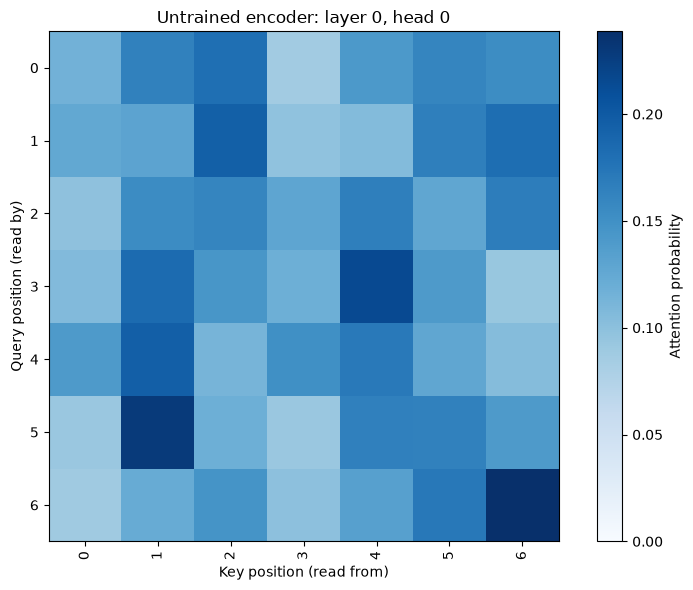

In [34]:
enc_plot_ids = enc_demo_batch["input_ids"][0].tolist()
enc_plot_labels = [str(i) for i in range(len(enc_plot_ids))]
show_table(["그림의 위치", "토큰 ID", "조각"],
           [[i, t, tokenizer.pieces[t]] for i, t in enumerate(enc_plot_ids)])
enc_plot_matrix = enc_demo_attentions[0][0, 0].cpu().numpy()
fig, ax = plt.subplots(figsize=(8, 6))
enc_plot_image = ax.imshow(enc_plot_matrix, cmap="Blues", vmin=0)
ax.set_xticks(range(len(enc_plot_labels)), enc_plot_labels, rotation=90)
ax.set_yticks(range(len(enc_plot_labels)), enc_plot_labels)
ax.set_xlabel("Key position (read from)")
ax.set_ylabel("Query position (read by)")
ax.set_title("Untrained encoder: layer 0, head 0")
fig.colorbar(enc_plot_image, ax=ax, label="Attention probability")
plt.tight_layout()
plt.show()
assert torch.allclose(enc_demo_attentions[0].sum(-1),
                      torch.ones_like(enc_demo_attentions[0].sum(-1)), atol=1e-6)

### 2.10 손으로 고쳐 볼 문제: softmax 축 하나가 틀리면

`[B,H,T,T]`에서 마지막 두 축의 크기가 같다는 점이 위험하다. `dim=-1` 대신 `dim=-2`를 써도 에러가 나지 않고 출력 shape도 같다. 다음 셀을 실행하기 전에 생각해 보자. 어떤 합이 1이 되어야 각 query가 key들을 섞는 가중치가 되는가?

In [35]:
axis_demo_scores = torch.tensor([[2., 0., 1.], [3., -1., 0.], [0., 1., 4.]])
axis_demo_right = torch.softmax(axis_demo_scores, dim=-1)
axis_demo_wrong = torch.softmax(axis_demo_scores, dim=-2)
show_table(
    ["구현", "행의 합", "열의 합"],
    [["마지막 축", axis_demo_right.sum(-1).tolist(), axis_demo_right.sum(-2).tolist()],
     ["끝에서 두 번째 축", axis_demo_wrong.sum(-1).tolist(),
      axis_demo_wrong.sum(-2).tolist()]],
)
assert torch.allclose(axis_demo_right.sum(-1), torch.ones(3))
assert not torch.allclose(axis_demo_wrong.sum(-1), torch.ones(3))

구현,행의 합,열의 합
마지막 축,"[0.9999998807907104, 1.0, 1.0]","[1.6186282634735107, 0.15379101037979126, 1.2275805473327637]"
끝에서 두 번째 축,"[0.5508375763893127, 0.8125629425048828, 1.6365995407104492]","[1.0000001192092896, 1.0, 1.0]"


<details><summary>풀이와 추가 실험</summary>

각 query는 모든 key를 후보로 삼는다. 따라서 query 위치를 고정한 행 안에서, key 축인 마지막 축의 합이 1이어야 한다. 잘못된 구현은 key 하나를 여러 query가 나눠 갖도록 열을 정규화한다. shape 검사만으로는 이 차이를 잡을 수 없다.

1. `MultiHeadSelfAttention`의 `dim=-1`을 일부러 `dim=-2`로 바꾼 복사본을 만들고 위의 행 합 검사를 붙여 보자. 원본 클래스는 뒤의 실습에 쓰므로 그대로 둔다.
2. key mask를 지운 복사본으로 PAD 추가 검사를 실행해 보자. PAD가 유효한 토큰의 출력을 바꾸는 경로를 설명할 수 있어야 한다.
3. `d_model=48, n_heads=5`를 사용하면 어느 지점에서 왜 실패해야 하는가? 48개 좌표를 같은 크기의 head 5개로 나눌 수 없으므로 설정 검사에서 실패해야 한다.
4. 위치 정보 없는 encoder의 출력에서 첫 위치만 골랐을 때와 모든 위치를 평균 냈을 때를 비교해 보자. 첫 위치 선택은 임의의 전체 순열에 불변이지 않다. `[CLS]` 위치를 고정하고 내용 토큰만 순열하면, 위치 정보가 없을 때 그 고정된 `[CLS]` 출력은 그대로다.

</details>

이제 클래스 이름을 가리고도 `ID → 세 테이블의 합 → QKV → key mask → softmax → V 가중합 → head 합치기 → residual/LN → FFN → residual/LN` 순서로 forward를 다시 적을 수 있어야 한다. 다음 장에서는 이 함수의 출력에 실제 학습 목적을 붙인다. 먼저 토큰 복원으로 문맥 학습을 살펴보고, 이어 문장 벡터와 검색 관련성 학습으로 넘어간다.

## 3. 빈칸을 복원하며 encoder를 학습한다

앞 장의 `TinyBert`는 토큰 ID를 문맥에 따라 변환한다. 아직 어떤 변환이 유용한지는 배우지 않았다. 층의 수를 늘리는 것만으로 문법이나 검색 관련성이 생기지는 않는다. 파라미터를 바꾸려면 먼저 **모델에게 풀 문제와 오답의 비용**을 정해야 한다.

이 장에서는 문장의 일부 토큰을 가리고 원래 ID를 맞히게 한다. 이 문제를 masked language modeling, 줄여서 MLM이라고 부른다. 입력은 손상된 문장이고 정답은 손상시키기 전의 토큰 ID이다. 사람이 별도로 정답을 달지 않아도 원문에서 정답을 만들 수 있으므로 자기지도학습에 해당한다.

원래 BERT는 WordPiece, 양방향 Transformer encoder, MLM과 다음 문장 예측(NSP)을 함께 사용했다. 여기서는 앞서 만든 BPE와 작은 encoder를 그대로 쓰고 MLM만 구현한다. 층 수와 학습량도 크게 줄였다. 따라서 BERT와 닮은 학습 경로를 직접 만드는 실습이지, 공개 BERT의 학습 결과를 재현하는 실험은 아니다. 원 논문의 MLM 설명은 [BERT §3.1](https://aclanthology.org/N19-1423.pdf)에 있다.

### 3.1 정답을 어디에 둘 것인가

토크나이저가 어떤 문장을 아래처럼 나눴다고 하자. 실제 분할 결과는 앞 장에서 학습한 merge에 따라 달라진다.

```text
원래 입력:  [CLS]   고양이   가   쥐   를   쫓다   [SEP]   [PAD]
학습 입력:  [CLS]   고양이   가 [MASK] 를   쫓다   [SEP]   [PAD]
정답 ID:     -100    -100 -100  쥐_ID -100  -100    -100    -100
```

`-100`은 vocabulary에 없는 값이다. 이 위치의 예측은 loss에서 제외하라는 표시로 사용한다. `[PAD]`의 ID인 `0`과 다르다. 정답을 `0`으로 채우면 모델은 거의 모든 위치에서 `[PAD]`를 맞히도록 학습된다.

빈칸을 만드는 mask와 attention mask도 다르다. `[MASK]`가 놓인 위치는 encoder 안에서 유효한 위치이므로 attention에 참여한다. `[PAD]` 위치만 key/value의 기여를 차단한다. 선택된 위치를 key mask에서도 지우면 다른 위치가 그 표현을 읽지 못하게 되어 별도의 모델이 된다. key mask는 query 위치의 출력을 없애는 연산은 아니라는 점도 구분하자.

| 이름 | 크기 | `True` 또는 유효한 값의 뜻 |
|---|---|---|
| `attention_mask` | `[B, T]` | 실제 입력에 속하는 위치 |
| `selected` | `[B, T]` | 이번에 복원을 학습할 위치 |
| `labels` | `[B, T]` | 선택 위치에는 원래 ID, 나머지에는 `-100` |
| `input_ids` | `[B, T]` | 선택 위치 일부를 바꾼 뒤 encoder에 넣을 ID |

일반 토큰 중 약 15%를 선택한다. 선택된 위치의 80%는 `[MASK]`, 10%는 임의의 일반 토큰으로 바꾸고, 나머지 10%는 그대로 둔다. 이 비율은 배치마다 정확히 맞추는 할당량이 아니라 각 위치의 추첨 확률이다. 짧은 문장에서 선택 위치가 하나도 없으면 이 실습은 한 위치를 추가로 뽑는다. 이 보정 때문에 실제 선택률은 15%보다 높을 수 있다.

그대로 두는 10%에서는 정답이 입력에 남는다. 임의 토큰 치환도 우연히 같은 ID를 뽑을 수 있다. 이는 정해 둔 학습 규칙의 일부이다. 따라서 모든 정답이 숨겨졌다고 해석하면 안 된다. 아래 진단에서는 선택 위치를 **전부 `[MASK]`로 바꿔서** 정답을 직접 보는 효과를 제외한다.

In [36]:
MLM_IGNORE = -100
MLM_FIRST_CONTENT_ID = 5  # 0..4 = PAD, UNK, CLS, SEP, MASK
MLM_MASK_ID = 4

def make_mlm_batch(clean_batch, generator, probability=0.15, mask_only=False):
    """원본 batch를 보존하고, 손상 입력과 별도 정답을 만든다. CPU 실습용."""
    if not 0.0 < probability <= 1.0:
        raise ValueError("probability는 (0, 1]이어야 합니다.")
    if tokenizer.vocab_size <= MLM_FIRST_CONTENT_ID:
        raise ValueError("일반 토큰이 한 개 이상 필요합니다.")
    original = clean_batch["input_ids"]
    eligible = clean_batch["attention_mask"].bool() & (original >= MLM_FIRST_CONTENT_ID)
    if not eligible.any(dim=1).all():
        raise ValueError("각 문장에 MLM 대상으로 쓸 일반 토큰이 필요합니다.")
    selected = (torch.rand(original.shape, generator=generator) < probability) & eligible
    for row in range(original.size(0)):
        if not selected[row].any():
            candidates = eligible[row].nonzero(as_tuple=True)[0]
            choice = torch.randint(len(candidates), (1,), generator=generator).item()
            selected[row, candidates[choice]] = True

    labels = torch.full_like(original, MLM_IGNORE)
    labels[selected] = original[selected]  # 입력을 바꾸기 전에 정답을 저장한다.
    changed = {key: value.clone() for key, value in clean_batch.items()}
    branch = torch.rand(original.shape, generator=generator)
    masked = selected if mask_only else selected & (branch < 0.8)
    randomized = torch.zeros_like(selected) if mask_only else selected & (branch >= 0.8) & (branch < 0.9)
    unchanged = selected & ~(masked | randomized)
    replacement = torch.randint(
        MLM_FIRST_CONTENT_ID, tokenizer.vocab_size, original.shape, generator=generator
    )
    changed["input_ids"][masked] = MLM_MASK_ID
    changed["input_ids"][randomized] = replacement[randomized]
    return changed, labels, {"selected": selected, "masked": masked,
                             "randomized": randomized, "unchanged": unchanged}

mlm_corpus = list(dict.fromkeys(DOCS + [query for query, _ in TRAIN]))
mlm_clean = pack_batch(mlm_corpus)
preview_clean = pack_batch([DOCS[0], DOCS[1]])
preview_batch, preview_labels, preview_marks = make_mlm_batch(
    preview_clean, torch.Generator().manual_seed(31), probability=0.4, mask_only=True
)
preview_rows = []
for position in range(int(preview_clean["attention_mask"][0].sum())):
    original_id = int(preview_clean["input_ids"][0, position])
    changed_id = int(preview_batch["input_ids"][0, position])
    label = int(preview_labels[0, position])
    preview_rows.append([position, tokenizer.pieces[original_id],
                         tokenizer.pieces[changed_id], label,
                         "loss에 포함" if label != MLM_IGNORE else "제외"])
show_table(["위치", "원문 토큰", "encoder가 보는 토큰", "정답 ID", "용도"], preview_rows)
assert preview_marks["selected"].any(dim=1).all()
assert torch.equal(preview_batch["attention_mask"], preview_clean["attention_mask"])
assert torch.all(preview_batch["input_ids"][preview_marks["selected"]] == MLM_MASK_ID)
assert torch.all(preview_labels[~preview_marks["selected"]] == MLM_IGNORE)

위치,원문 토큰,encoder가 보는 토큰,정답 ID,용도
0,[CLS],[CLS],-100,제외
1,▁고양이,▁고양이,-100,제외
2,▁가,[MASK],142,loss에 포함
3,▁쥐,▁쥐,-100,제외
4,▁를,[MASK],143,loss에 포함
5,▁쫓다,▁쫓다,-100,제외
6,[SEP],[SEP],-100,제외


표의 정답 열은 모델의 입력이 아니다. encoder에는 `input_ids`, `attention_mask`, `token_type_ids`만 전달할 것이다. 원문 ID를 별도 인자로 encoder에 전달하거나 손상시키기 전 embedding을 재사용하면 정답을 우회해서 보여 주게 된다.

여기서는 공개 문서 `DOCS`와 학습 질의 `TRAIN`만 MLM에 사용한다. 검색 대상 문서를 학습 때 볼 수 있는 고정 문서집 조건이다. 검증·테스트 질의는 이 목록에 넣지 않는다. 문서까지 처음 보는 검색 문제를 평가하려면 문서 집합도 따로 나누어야 한다.

### 3.2 문맥 벡터를 vocabulary의 점수로 바꾼다

encoder의 출력 `H`는 `[B, T, D]`이다. 각 위치의 벡터를 vocabulary의 ID 중 하나로 분류하려면 마지막 축을 `D`에서 `V`로 바꿔야 한다.

$$
u_{bt}=\operatorname{LayerNorm}(\operatorname{GELU}(W_h h_{bt}+b_h)),
\qquad \ell_{btv}=u_{bt}^{\mathsf T} E_v+b_v.
$$

`E`는 입력에서 사용한 바로 그 토큰 임베딩 행렬이다. PyTorch의 `F.linear(u, E, bias)`는 마지막 축에 `u @ E.T + bias`를 계산한다. `E`의 크기는 `[V, D]`이므로 결과는 `[B, T, V]`이다. 입력에서는 행을 조회하고, 출력에서는 모든 행과 내적한다. 같은 파라미터를 두 용도로 쓰는 것을 **weight tying**이라고 한다.

입력과 출력에 따로 행렬을 만들 수도 있다. 그 경우 두 행렬은 서로 다른 역할에 맞게 움직이고 파라미터 수도 늘어난다. 여기서는 공유했을 때 gradient가 어떻게 합쳐지는지를 볼 수 있게 tying을 사용한다.

In [37]:
class MaskedLanguageModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.encoder = TinyBert(config)
        self.dense = nn.Linear(config.d_model, config.d_model)
        self.norm = nn.LayerNorm(config.d_model)
        self.vocab_bias = nn.Parameter(torch.zeros(config.vocab_size))
        forbidden = torch.arange(config.vocab_size) < MLM_FIRST_CONTENT_ID
        self.register_buffer("forbidden_output", forbidden)

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        hidden = self.encoder(input_ids, attention_mask, token_type_ids)
        transformed = self.norm(F.gelu(self.dense(hidden)))
        logits = F.linear(transformed, self.encoder.embeddings.token.weight, self.vocab_bias)
        # 이 교재의 정답은 일반 토큰뿐이다. 특수 ID는 출력 후보에서 제외한다.
        return logits.masked_fill(self.forbidden_output, float("-inf"))

def mlm_forward(model, batch):
    return model(batch["input_ids"], batch["attention_mask"], batch["token_type_ids"])

def mlm_loss(logits, labels):
    if not (labels != MLM_IGNORE).any():
        raise ValueError("복원 정답이 없습니다. 전부 ignore인 loss는 계산하지 않습니다.")
    return F.cross_entropy(
        logits.reshape(-1, logits.size(-1)), labels.reshape(-1), ignore_index=MLM_IGNORE
    )

torch.manual_seed(41)
encoder_config = ModelConfig(vocab_size=tokenizer.vocab_size)
mlm_model = MaskedLanguageModel(encoder_config)
preview_logits = mlm_forward(mlm_model, preview_batch)
print("encoder 입력:", tuple(preview_batch["input_ids"].shape))
print("vocabulary 점수:", tuple(preview_logits.shape))
print("복원할 위치 수:", int((preview_labels != MLM_IGNORE).sum()))
print("초기 loss:", round(float(mlm_loss(preview_logits, preview_labels).detach()), 4))

encoder 입력: (2, 7)
vocabulary 점수: (2, 7, 242)
복원할 위치 수: 6
초기 loss: 5.4122


여기서 특수 토큰의 출력 점수를 `-inf`로 바꾼 것은 이 실습의 설계이다. 정답에서 특수 토큰을 제외하는 것과 출력 후보에서 제외하는 것은 서로 다른 조치이다. 정답으로 한 번도 등장하지 않아도 softmax의 분모에 있으면 gradient를 받을 수 있다.

또한 `[UNK]`를 정답에서 제외하므로, 새 도메인에서 미등록 문자가 잦다면 학습할 정보를 버리게 된다. 앞 장에서 미등록 문자의 처리 방식을 확인한 이유가 여기에도 연결된다.

### 3.3 loss를 한 위치씩 손으로 확인한다

정답이 있는 위치 집합을 $S$라고 쓰면, 이 배치의 loss는 다음과 같다.

$$
L_{\mathrm{MLM}}=-\frac{1}{|S|}\sum_{(b,t)\in S}
\log\frac{\exp(\ell_{bt,y_{bt}})}{\sum_{v=5}^{V-1}\exp(\ell_{btv})}.
$$

합의 분모는 문장 수가 아니라 선택한 토큰 수이다. 길이가 긴 문장은 보통 더 많은 복원 위치를 제공하므로 배치의 loss에도 더 많이 기여한다. 단어 하나가 세 subword로 나뉘면 세 개의 분류 위치가 된다. 이 구현은 단어 전체를 함께 가리는 whole-word masking을 하지 않는다.

`F.cross_entropy`는 logits에 log-softmax와 정답 log 확률 선택을 수행한다. 호출 전에 `softmax`를 적용하지 않는다. 먼저 확률로 바꾼 값을 넣으면 그 확률을 다시 점수로 취급해서 다른 목적함수가 된다. `ignore_index=-100`인 정답은 평균의 분모에서도 제외된다. [PyTorch CrossEntropyLoss](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)

아래에서는 `[B,T,V]`에서 앞의 두 축을 합친다. 토큰 위치를 일렬로 펼쳐 B*T개의 위치를 각각 V개 후보로 분류하는 문제로 본 것이다. `-100`인 위치를 먼저 고르는 방법과 결과가 같아야 한다.

In [38]:
selected_logits = preview_logits[preview_labels != MLM_IGNORE]  # [선택 위치 수, V]
selected_targets = preview_labels[preview_labels != MLM_IGNORE]
log_probabilities = selected_logits.log_softmax(dim=-1)
manual_terms = -log_probabilities[torch.arange(len(selected_targets)), selected_targets]
manual_loss = manual_terms.mean()
library_loss = mlm_loss(preview_logits, preview_labels)
torch.testing.assert_close(manual_loss, library_loss)
show_table(["선택 위치", "정답 토큰", "정답 확률", "-log 확률"], [
    [i, tokenizer.pieces[int(selected_targets[i])],
     f"{float((-manual_terms[i]).exp().detach()):.5f}",
     f"{float(manual_terms[i].detach()):.4f}"]
    for i in range(min(6, len(selected_targets)))
])
print("손계산 평균과 cross_entropy의 차이:", float((manual_loss - library_loss).abs().detach()))

선택 위치,정답 토큰,정답 확률,-log 확률
0,▁가,0.00437,5.4330
1,▁를,0.00513,5.2731
2,▁쥐,0.00379,5.5751
3,▁가,0.00437,5.4336
4,▁고양이,0.00417,5.4794
5,▁를,0.00510,5.2790


손계산 평균과 cross_entropy의 차이: 0.0


일반 토큰이 `V-5`개이고 확률이 균등하다면 loss는 `log(V-5)`이다. 초기 모델은 완전히 균등하지 않으므로 그 값과 정확히 같지는 않는다. 이 기준은 규모를 읽는 용도이다. vocabulary가 다른 두 모델의 loss를 숫자만으로 비교하는 데 사용하면 안 된다.

### 3.4 입력에 없던 임베딩 행도 바뀔 수 있다

앞 장의 lookup 실험에서는 조회한 ID에만 gradient가 생겼다. 지금의 `E`는 출력 분류기에도 참여한다. 한 복원 위치에서 vocabulary 점수에 대한 미분은 다음과 같다.

$$
\frac{\partial L}{\partial\ell_v}=p_v-\mathbf{1}[v=y],
\qquad
\left.\frac{\partial L}{\partial E_v}\right|_{\mathrm{output}}
=(p_v-\mathbf{1}[v=y])u.
$$

여러 위치의 평균에서는 이 항들을 더하고 선택 위치 수로 나눈다. 정답이 아닌 일반 토큰도 `p_v`가 0이 아니면 output 쪽 gradient를 받는다. 전체 `E`의 gradient에는 이 항과 encoder의 lookup을 통해 돌아온 항이 더해진다.

`nn.Embedding(padding_idx=0)`은 lookup 연산이 PAD 행에 gradient를 쌓지 않게 한다. 그러나 같은 행렬을 `F.linear`에 넘기면 그 연산까지 차단해 주지는 않는다. 입력에 PAD가 없어도 출력 softmax의 PAD 점수로부터 gradient가 생길 수 있다. [PyTorch Embedding](https://pytorch.org/docs/stable/generated/torch.nn.Embedding.html)

아래 작은 실험은 encoder를 잠시 빼고 이 경로만 확인한다. 입력에는 ID 5 하나만 있다. 정답은 6이고 ID 7은 입력에도 정답에도 없다.

In [39]:
torch.manual_seed(42)
toy_table = nn.Embedding(8, 3, padding_idx=0)
toy_ids = torch.tensor([5])
toy_target = torch.tensor([6])
toy_forbidden = torch.arange(8) < MLM_FIRST_CONTENT_ID

def inspect_tied_grad(block_special):
    toy_table.zero_grad(set_to_none=True)
    representation = toy_table(toy_ids)  # [1, 3]
    scores = F.linear(representation, toy_table.weight)  # [1, 8]
    if block_special:
        scores = scores.masked_fill(toy_forbidden, float("-inf"))
    F.cross_entropy(scores, toy_target).backward()
    return toy_table.weight.grad.detach().norm(dim=-1).clone()

all_output_grad = inspect_tied_grad(False)
content_output_grad = inspect_tied_grad(True)
show_table(["행", "입력에 등장", "전체 ID를 출력 후보로", "일반 ID만 출력 후보로"], [
    [token_id, token_id == 5, f"{float(all_output_grad[token_id]):.6f}",
     f"{float(content_output_grad[token_id]):.6f}"] for token_id in [0, 5, 6, 7]
])
assert all_output_grad[0] > 0             # padding_idx만으로는 막히지 않는다.
assert content_output_grad[0] == 0        # 출력 경로도 막았을 때 0이다.
assert content_output_grad[7] > 0         # 입력에 없던 일반 토큰도 업데이트된다.

행,입력에 등장,전체 ID를 출력 후보로,일반 ID만 출력 후보로
0,False,0.043315,0.000000
5,True,1.516816,0.736934
6,False,0.491524,0.361196
7,False,0.049792,0.166166


PAD 행의 gradient가 0이라는 것과 PAD 행의 값이 0이라는 것도 구별해야 한다. optimizer에 weight decay가 있으면 gradient가 0이어도 기존의 0이 아닌 값은 달라질 수 있다. 여기서는 앞 장에서 PAD 행을 0으로 초기화했고, 입력과 출력의 gradient 경로를 모두 막았으므로 0이 유지된다.

### 3.5 같은 복원 문제를 학습 전후에 풀어 본다

작은 말뭉치 전체에서 진단용 빈칸을 한 번 만들어 고정한다. 학습 중에는 같은 원문에서 매번 새 위치를 선택한다. 진단용 빈칸은 전부 `[MASK]`로 바꾼다. 따라서 학습 loss와 진단 loss의 숫자는 직접 비교하지 않고 각각의 용도로 읽는다.

진단 원문은 학습 원문과 같다. 이 정확도는 외워서라도 주어진 문제를 잘 풀게 되었는지 확인하는 **학습 자료 내 진단**이다. 언어 이해 능력이나 새로운 질의에서의 검색 성능을 추정하는 평가가 아니다. 뒤에서 따로 보관한 검색 질의로 retrieval을 평가한다.

In [40]:
diagnostic_batch, diagnostic_labels, diagnostic_marks = make_mlm_batch(
    mlm_clean, torch.Generator().manual_seed(44), probability=0.2, mask_only=True
)

@torch.no_grad()
def diagnose_mlm(model, batch, labels):
    was_training = model.training
    model.eval()
    logits = mlm_forward(model, batch)
    active = labels != MLM_IGNORE
    metrics = {
        "loss": float(mlm_loss(logits, labels)),
        "accuracy": float((logits.argmax(-1)[active] == labels[active]).float().mean()),
        "count": int(active.sum()),
    }
    model.train(was_training)
    return metrics

mlm_before = diagnose_mlm(mlm_model, diagnostic_batch, diagnostic_labels)
print("고정 진단 위치:", mlm_before["count"])
print("학습 전 loss:", round(mlm_before["loss"], 4),
      "정확도:", f"{mlm_before['accuracy']:.1%}")

고정 진단 위치: 93
학습 전 loss: 5.4899 정확도: 0.0%


아래 loop는 96번의 optimizer step을 수행한다. 문장을 모두 한 번씩 보는 epoch 수와는 다른 단위이다. 매번 문장을 복원 추출하므로 같은 문장을 다시 뽑을 수 있다. 이 경우에도 빈칸 위치는 다시 추첨된다.

`zero_grad → forward → loss → backward → clip → step`의 순서를 따라 읽어 보자. `loss.backward()`까지는 gradient를 계산할 뿐 파라미터 값은 바꾸지 않는다. `optimizer.step()`이 실제 값을 바꾼다. gradient clipping은 전체 gradient norm이 너무 클 때 모든 gradient를 같은 비율로 줄인다.

In [41]:
torch.set_num_threads(1)
mlm_training_rng = torch.Generator().manual_seed(45)
mlm_optimizer = torch.optim.AdamW(mlm_model.parameters(), lr=3e-3, weight_decay=0.01)
mlm_history = []
mlm_steps = 96
mlm_batch_size = min(16, len(mlm_corpus))
mlm_started = time.perf_counter()
mlm_model.train()
mlm_embedding_before = mlm_model.encoder.embeddings.token.weight.detach().clone()

for step in range(mlm_steps):
    indices = torch.randint(len(mlm_corpus), (mlm_batch_size,), generator=mlm_training_rng)
    clean = {key: value[indices] for key, value in mlm_clean.items()}
    damaged, labels, _ = make_mlm_batch(clean, mlm_training_rng)
    mlm_optimizer.zero_grad(set_to_none=True)
    logits = mlm_forward(mlm_model, damaged)
    loss = mlm_loss(logits, labels)
    if not torch.isfinite(loss):
        raise FloatingPointError(f"MLM step {step}에서 loss가 유한하지 않습니다.")
    loss.backward()
    nn.utils.clip_grad_norm_(mlm_model.parameters(), max_norm=1.0)
    assert torch.count_nonzero(mlm_model.encoder.embeddings.token.weight.grad[0]) == 0
    mlm_optimizer.step()
    mlm_history.append(float(loss.detach()))

mlm_after = diagnose_mlm(mlm_model, diagnostic_batch, diagnostic_labels)
pretrained_encoder = copy.deepcopy(mlm_model.encoder).eval()
assert torch.count_nonzero(pretrained_encoder.embeddings.token.weight[0]) == 0
show_table(["고정 빈칸 진단", "학습 전", "학습 후"], [
    ["loss", f"{mlm_before['loss']:.4f}", f"{mlm_after['loss']:.4f}"],
    ["선택 토큰 정확도", f"{mlm_before['accuracy']:.1%}", f"{mlm_after['accuracy']:.1%}"],
])
print(f"{mlm_steps} step / {time.perf_counter() - mlm_started:.2f}초")
print("토큰 테이블 변화의 L2 norm:", round(float(
    (pretrained_encoder.embeddings.token.weight.detach() - mlm_embedding_before).norm()
), 4))

고정 빈칸 진단,학습 전,학습 후
loss,5.4899,2.8387
선택 토큰 정확도,0.0%,28.0%


96 step / 0.61초
토큰 테이블 변화의 L2 norm: 8.3861


정확도가 100%가 되어야 성공하는 실험은 아니다. 같은 주변 문맥에 여러 정답이 가능한 빈칸도 있고, 작은 모델은 위치나 빈도가 높은 토큰에 의존할 수 있다. 실행이 정상인지 볼 때는 loss가 유한한지, 파라미터가 바뀌는지, 같은 진단에서 예측이 어떻게 달라졌는지를 함께 본다.

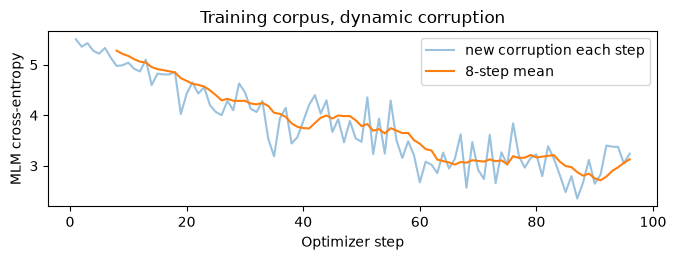

원문,가린 위치,정답 조각,예측 조각,일치
고양이 가 쥐 를 쫓다,3,▁쥐,▁토끼,False
쥐 가 고양이 를 쫓다,1,▁쥐,▁토끼,False
개 가 토끼 를 돕다,3,▁토끼,▁토끼,True
토끼 가 개 를 돕다,5,▁돕다,▁가르치다,False
교사 가 제자 를 가르치다,5,▁가르치다,▁가르치다,True
제자 가 교사 를 가르치다,2,▁가,▁가,True
계정 비밀번호 초기화 안내,6,▁,떻,False
환불 처리 이후 입금 소요 기간,2,불,원,False
환불 처리 이후 입금 소요 기간,3,▁,▁,True
환불 처리 이후 입금 소요 기간,5,리,▁어,False


In [42]:
fig, ax = plt.subplots(figsize=(7, 2.7))
ax.plot(range(1, len(mlm_history) + 1), mlm_history, alpha=0.45, label="new corruption each step")
window = 8
running = np.convolve(mlm_history, np.ones(window) / window, mode="valid")
ax.plot(range(window, len(mlm_history) + 1), running, label="8-step mean")
ax.set(xlabel="Optimizer step", ylabel="MLM cross-entropy", title="Training corpus, dynamic corruption")
ax.legend()
plt.tight_layout()
plt.show()

mlm_model.eval()
with torch.no_grad():
    diagnostic_predictions = mlm_forward(mlm_model, diagnostic_batch).argmax(-1)
examples = []
for row, position in diagnostic_marks["selected"].nonzero().tolist()[:10]:
    target_id = int(diagnostic_labels[row, position])
    prediction_id = int(diagnostic_predictions[row, position])
    examples.append([mlm_corpus[row], position, tokenizer.pieces[target_id],
                     tokenizer.pieces[prediction_id], target_id == prediction_id])
show_table(["원문", "가린 위치", "정답 조각", "예측 조각", "일치"], examples)

### 3.6 직접 바꾸어 볼 두 가지

첫째, `probability=1.0, mask_only=True`라면 문장 안의 일반 토큰이 모두 `[MASK]`가 된다. 위치와 길이, 특수 토큰은 남지만 원래 일반 토큰의 문맥은 사라진다. 이 입력에서 잘 맞히더라도 주변 단어를 이용했다고 말할 수 없다. 아래 셀은 실제로 그렇게 바뀌는지 확인한다.

둘째, 선택하지 않은 위치의 logits를 크게 바꾸면 loss가 변할까? 이 구현에서는 변하지 않아야 한다. `ignore_index`의 의미를 값과 미분 양쪽에서 확인한다. 모델을 재학습하지 않으므로 앞의 결과는 유지된다.

In [43]:
# 연습 해설 1: 모든 일반 토큰을 숨겨도 attention_mask는 유지된다.
fully_hidden, fully_hidden_labels, _ = make_mlm_batch(
    preview_clean, torch.Generator().manual_seed(48), probability=1.0, mask_only=True
)
content_positions = preview_clean["input_ids"] >= MLM_FIRST_CONTENT_ID
assert torch.all(fully_hidden["input_ids"][content_positions] == MLM_MASK_ID)
assert torch.equal(fully_hidden["attention_mask"], preview_clean["attention_mask"])
assert torch.equal(fully_hidden_labels[content_positions], preview_clean["input_ids"][content_positions])

# 연습 해설 2: 무시한 위치에는 직접적인 출력 loss의 gradient가 없다.
torch.manual_seed(49)
exercise_logits = torch.randn(1, 3, 8, requires_grad=True)
exercise_labels = torch.tensor([[6, MLM_IGNORE, 5]])
exercise_loss = mlm_loss(exercise_logits, exercise_labels)
exercise_gradient, = torch.autograd.grad(exercise_loss, exercise_logits)
perturbed = exercise_logits.detach().clone()
perturbed[0, 1] = torch.arange(8) * 100.0
torch.testing.assert_close(exercise_loss.detach(), mlm_loss(perturbed, exercise_labels))
assert torch.count_nonzero(exercise_gradient[0, 1]) == 0
print("전체 가림과 ignore_index의 값·미분 확인 완료")

전체 가림과 ignore_index의 값·미분 확인 완료


마지막 결과를 encoder의 문맥 경로까지 확대 해석하면 안 된다. 선택하지 않은 위치의 **출력 logits**에는 직접 loss가 없지만, 그 위치의 입력 표현은 다른 위치의 attention에 쓰일 수 있다. 따라서 선택하지 않은 토큰의 입력 임베딩과 encoder 상태에는 gradient가 도달할 수 있다.

이제 `pretrained_encoder`에는 MLM으로 갱신한 파라미터가 들어 있다. 다음 장에서는 vocabulary를 맞히던 `dense`, `norm`, `vocab_bias`를 사용하지 않고 encoder의 `[B,T,D]` 출력을 문장별 `[B,D]`로 모은다. 이후 검색 관련성에 맞춘 loss와 새 optimizer로 학습한다. 토큰을 잘 복원하는 것과 관련 문서를 가까이 배치하는 것은 서로 다른 요구이므로, 이 두 번째 학습이 왜 필요한지 결과를 비교하며 확인한다.

## 4. 토큰마다 나온 벡터를 문장 하나의 벡터로 묶기

MLM head에 들어가던 encoder의 출력은 토큰 위치마다 있다. 길이 20인 문장의 hidden state는 `[1, 20, 48]`이고, MLM head는 이를 `[1, 20, V]`의 어휘 점수로 바꾸었다. 이제 그 head를 떼고 문장 하나의 벡터를 만든다. 문서마다 벡터 하나를 미리 계산해 두면 질의가 들어올 때 행렬곱으로 관련성 점수를 계산할 수 있다.

토큰 표현을 문장 표현으로 묶는 연산을 pooling이라고 부른다. 여기에는 정답 하나가 정해져 있지 않다. `[CLS]` 위치를 쓰거나, 내용 토큰의 평균을 쓰거나, 추가적인 attention pooling을 학습할 수 있다. 어떤 방법을 택하든 그 표현이 검색 관련성을 담도록 학습해야 한다. `[CLS]`라는 이름 자체가 그 벡터를 좋은 문장 요약으로 만들지는 않는다.

### 4.1 평균을 낼 때 무엇을 분모에 넣을 것인가

내용 토큰을 가리키는 mask를 $m_t\in\{0,1\}$라고 쓰면 평균은 다음과 같다.

$$u_b=\frac{\sum_t m_{bt}H_{bt}}{\sum_t m_{bt}}.$$

`H`의 shape는 `[B, T, D]`, mask는 `[B, T]`다. mask 끝에 차원 하나를 더해 `[B, T, 1]`로 만들면 같은 mask 값이 D개의 좌표에 적용된다. 합산할 축은 토큰 축인 `dim=1`이다. 분모는 실제 내용 토큰 수다. 배치에서 가장 긴 문장에 맞춘 T를 분모에 넣으면, 같은 문장이 어떤 문장과 함께 배치되는지에 따라 크기가 달라진다.

encoder의 key padding mask와 이 mask는 역할이 다르다. 앞의 mask는 PAD를 읽지 못하게 하고, 지금의 mask는 PAD 위치에서 나온 출력을 평균에 넣지 못하게 한다. 앞에서 위치와 segment 벡터, bias를 더했으므로 PAD 위치의 hidden state가 0이라고 가정하면 안 된다. 이 실습에서는 `[CLS]`, `[SEP]`도 평균에서 뺀다. 다른 선택도 가능하지만 학습과 추론에서 같은 규칙을 써야 한다.

In [44]:
def masked_mean(hidden, pool_mask):
    counts = pool_mask.sum(dim=1, keepdim=True)
    if (counts == 0).any():
        raise ValueError("평균을 낼 내용 토큰이 없는 문장이 있습니다.")
    weights = pool_mask.unsqueeze(-1).to(hidden.dtype)
    return (hidden * weights).sum(dim=1) / counts.to(hidden.dtype)

pool_example = torch.tensor([[[1., 2.], [3., 4.], [100., 100.]]])
pool_example_mask = torch.tensor([[True, True, False]])
print("올바른 평균:", masked_mean(pool_example, pool_example_mask))
print("mask를 생략한 평균:", pool_example.mean(dim=1))
torch.testing.assert_close(masked_mean(pool_example, pool_example_mask), torch.tensor([[2., 3.]]))

올바른 평균: tensor([[2., 3.]])
mask를 생략한 평균: tensor([[34.6667, 35.3333]])


마지막 위치의 100은 PAD의 hidden state를 흉내 낸 값이다. 값이 크든 작든 mask가 False인 위치는 결과에 영향을 주지 않아야 한다. 위의 첫 출력은 `[2, 3]`이다.

### 4.2 차원 축소와 길이 정규화

encoder의 48차원 평균을 32차원으로 바꾼다. 이는 검색 벡터의 저장 비용을 정하는 별도의 설계다. 선형층의 가중치도 검색 loss로 학습한다.

$$v=Wu,\qquad z=\frac{v}{\|v\|_2}.$$

두 벡터의 길이가 1이면 내적은 cosine similarity와 같다. 아래 구현은 norm이 0에 가까울 때 0으로 나누지 않도록 epsilon을 사용한다. 정규화를 생략한 내적에서는 벡터 길이도 점수에 관여한다. 따라서 정규화 여부는 인덱스를 만들 때와 질의를 처리할 때 함께 고정해야 한다.

정규화의 미분도 계산해 둘 수 있다. $r=\sqrt{v^Tv}$, $z=v/r$일 때 $dr=v^Tdv/r$이다. 이를 대입하면

$$dz=\frac{1}{r}dv-\frac{v}{r^2}dr
=\frac{I-zz^T}{r}dv.$$

따라서 앞에서 도착한 gradient가 $g_z$라면 $g_v=(I-zz^T)g_z/r$이다. 현재 벡터 방향의 성분을 빼므로 점수 학습은 단순히 벡터를 길게 늘리는 방식으로 해결되지 않는다. 이 식은 norm이 epsilon보다 큰 영역에 적용된다.

In [45]:
class SentenceEncoder(nn.Module):
    def __init__(self, encoder, output_dim=32, pooling="mean", use_positions=True):
        super().__init__()
        if pooling not in {"mean", "cls"}:
            raise ValueError("pooling은 mean 또는 cls여야 합니다.")
        self.encoder = encoder
        self.max_len = encoder.config.max_len
        self.pooling = pooling
        self.use_positions = use_positions
        self.output_dim = output_dim
        self.projection = nn.Linear(encoder.config.d_model, output_dim, bias=False)

    def forward(self, batch):
        hidden = self.encoder(
            batch["input_ids"], batch["attention_mask"], batch["token_type_ids"],
            use_positions=self.use_positions,
        )
        pooled = masked_mean(hidden, batch["pool_mask"]) if self.pooling == "mean" else hidden[:, 0]
        projected = self.projection(pooled)
        return F.normalize(projected, p=2, dim=-1, eps=1e-12)

def encode_texts(model, texts, tokenizer=tokenizer):
    return model(pack_batch(texts, tokenizer=tokenizer, max_len=model.max_len))

torch.manual_seed(17)
initial_retriever = SentenceEncoder(copy.deepcopy(pretrained_encoder)).eval()
with torch.no_grad():
    sample_vectors = encode_texts(initial_retriever, DOCS[:3])
show_table(["내용", "값"], [
    ["문장 벡터 shape", tuple(sample_vectors.shape)],
    ["각 벡터의 L2 norm", [round(x, 5) for x in sample_vectors.norm(dim=-1).tolist()]],
    ["문서 0과 1의 cosine", round(float(sample_vectors[0] @ sample_vectors[1]), 5)],
])

내용,값
문장 벡터 shape,"(3, 32)"
각 벡터의 L2 norm,"[1.0, 1.0, 1.0]"
문서 0과 1의 cosine,0.99974


이 시점의 encoder는 MLM을 배웠지만 projection은 새로 초기화했다. 문장 벡터를 계산할 수 있게 됐다는 사실과 검색이 잘된다는 사실을 구분해야 한다. 다음 장에서 이 벡터들의 관계를 검색 정답에 맞춰 바꾼다.

### 4.3 모든 좌표에 이름을 붙일 수는 없다

온톨로지에서는 관계의 이름과 방향을 명시한다. 임베딩의 한 좌표가 그 관계 하나를 전담해야 하는 것은 아니다. 검색 출력 벡터 전체에 같은 직교행렬 R을 곱하면

$$ (Rz_q)^T(Rz_d)=z_q^TR^TRz_d=z_q^Tz_d $$

이므로 점수는 변하지 않는다. 그만큼 검색 목적만으로 좌표축의 의미가 유일하게 결정되지는 않는다. 이를 실제 벡터로 확인해 보자.

In [46]:
torch.manual_seed(19)
rotation, _ = torch.linalg.qr(torch.randn(32, 32))
original_scores = sample_vectors @ sample_vectors.T
rotated_vectors = sample_vectors @ rotation
rotated_scores = rotated_vectors @ rotated_vectors.T
torch.testing.assert_close(original_scores, rotated_scores, atol=1e-6, rtol=1e-5)
print("좌표를 회전시킨 뒤 점수의 최대 차이:", float((original_scores - rotated_scores).abs().max()))

좌표를 회전시킨 뒤 점수의 최대 차이: 2.384185791015625e-07


이것은 검색 출력 공간에 관한 성질이다. encoder의 모든 중간 파라미터를 마음대로 회전해도 동일한 모델이 된다는 뜻은 아니다. 또한 입력 임베딩에서 ‘추격’에 가까운 토큰을 나열하는 것만으로 최종 검색 결과를 설명할 수도 없다. 입력 표현은 attention과 projection을 거쳐 다른 표현으로 바뀐다.

### 4.4 비교할 평균 모델을 하나 더 만든다

문맥 encoder 없이도 검색 loss로 토큰 테이블을 학습할 수 있다. 이 모델을 같이 두면 학습 목적의 효과와 구조의 제한을 구분하기 쉽다. 시작 토큰 테이블은 위 MLM encoder에서 복사하고 projection의 초기값도 같은 seed로 맞춘다. 이후 두 모델은 독립적으로 학습한다.

평균 모델에서는 같은 ID들의 multiset을 가진 두 문서를 구분할 수 없다. 같은 행들을 같은 횟수 더하기 때문이다. 그 뒤에 선형층이나 비선형층을 더해도, 동일한 입력 벡터에 적용하면 동일한 출력이 나온다.

In [47]:
class MeanRetriever(nn.Module):
    def __init__(self, token_embedding, output_dim=32, max_len=96):
        super().__init__()
        self.token = copy.deepcopy(token_embedding)
        self.max_len = max_len
        self.projection = nn.Linear(token_embedding.embedding_dim, output_dim, bias=False)

    def forward(self, batch):
        ids = batch["input_ids"]
        vectors = self.token(ids)
        # 같은 multiset은 합산 순서까지 맞춰 부동소수점 오차에 의한 가짜 순위를 없앤다.
        order = ids.argsort(dim=1, stable=True)
        vectors = vectors.gather(1, order.unsqueeze(-1).expand_as(vectors))
        pool_mask = batch["pool_mask"].gather(1, order)
        pooled = masked_mean(vectors, pool_mask)
        return F.normalize(self.projection(pooled), dim=-1)

torch.manual_seed(17)
mean_initial = MeanRetriever(pretrained_encoder.embeddings.token, max_len=encoder_config.max_len).eval()
pair_ids = [0, 1]
pair_batch = pack_batch([DOCS[i] for i in pair_ids])
content_id_rows = [row[mask].tolist() for row, mask in zip(pair_batch["input_ids"], pair_batch["pool_mask"])]
assert sorted(content_id_rows[0]) == sorted(content_id_rows[1])
with torch.no_grad():
    pair_mean_vectors = mean_initial(pair_batch)
torch.testing.assert_close(pair_mean_vectors[0], pair_mean_vectors[1], atol=0, rtol=0)
print("같은 BPE 토큰 구성:", sorted(content_id_rows[0]) == sorted(content_id_rows[1]))
print("평균 모델의 두 문서 벡터 차이:", float((pair_mean_vectors[0] - pair_mean_vectors[1]).norm()))

같은 BPE 토큰 구성: True
평균 모델의 두 문서 벡터 차이: 0.0


문자열을 보며 ‘단어가 같으니 평균도 같다’고 추측하는 데서 끝내지 않고, 실제 tokenizer의 ID까지 확인했다. BPE가 단어 경계를 넘어 merge하거나, 두 표현의 정규화 결과가 달라지면 이 최소쌍의 조건도 달라질 수 있다. 구조에 관한 주장은 모델에 들어가는 실제 입력으로 확인해야 한다.

## 5. 검색 정답으로 벡터 공간을 학습하기

이제 문장마다 32차원 벡터가 나온다. 검색 결과는 질의 벡터와 각 문서 벡터의 내적을 큰 순서로 정렬하면 얻을 수 있다. 아직 학습할 것이 남아 있다. 앞의 MLM은 가려진 토큰을 복원하는 문제였고, 지금 풀 문제는 질의에 답하는 문서를 고르는 문제다. 두 문제는 사용하는 encoder가 같아도 정답의 단위와 loss가 다르다.

### 5.1 점수 행렬의 행과 열

학습 질의 48개를 쌓은 벡터를 $Q\in\mathbb{R}^{48\times32}$, 문서 12개를 쌓은 벡터를 $D\in\mathbb{R}^{12\times32}$라고 하자. $QD^T$는 `[48, 12]`다. **행 하나가 질의 하나이고 열 하나가 문서 하나**다. 여기서 Q와 D는 완성된 문장 벡터다. 앞 장 attention 내부의 query/key/value와는 계산 단계가 다르다.

정답 배열에는 각 질의가 가리키는 문서의 열 번호를 넣는다. 같은 문서를 가리키는 질의가 여러 개 있으므로 대각선이 정답인 행렬은 아니다. `torch.arange(48)`을 정답으로 쓰면 이 데이터의 label 구조를 잘못 옮긴 것이다.

In [48]:
train_batch = pack_batch([query for query, _ in TRAIN], max_len=encoder_config.max_len)
document_batch = pack_batch(DOCS, max_len=encoder_config.max_len)
train_targets = torch.tensor([target for _, target in TRAIN], dtype=torch.long)

with torch.no_grad():
    Q = initial_retriever(train_batch)
    D = initial_retriever(document_batch)
    S = Q @ D.T
print("Q:", tuple(Q.shape), "D:", tuple(D.shape), "S:", tuple(S.shape))
show_table(["질의", "정답 열", "그 열의 문서"],
           [(query, target, DOC_NAMES[target]) for query, target in TRAIN[:5]])

Q: (48, 32) D: (12, 32) S: (48, 12)


질의,정답 열,그 열의 문서
고양이 가 쥐 를 추격 하다,0,고양이가 쥐를 쫓음
고양이 가 쥐 를 뒤쫓다,0,고양이가 쥐를 쫓음
고양이 가 쥐 를 쫓다 설명,0,고양이가 쥐를 쫓음
고양이 가 쥐 를 추격 장면,0,고양이가 쥐를 쫓음
쥐 가 고양이 를 추격 하다,1,쥐가 고양이를 쫓음


질의와 문서는 같은 encoder 파라미터를 쓰지만 입력은 따로 처리한다. 이를 가중치를 공유하는 bi-encoder라고 부른다. 두 개의 서로 다른 encoder를 학습하는 설계도 가능하다. 문서를 질의와 독립적으로 인코딩한다는 성질 때문에 추론 시 문서 벡터를 미리 저장할 수 있다. 반대로 질의와 문서의 모든 토큰을 한 번에 넣는 cross-encoder는 질의마다 세밀한 상호작용을 계산할 수 있지만, 문서별 벡터 하나만 미리 계산해 두는 방식으로 같은 점수를 얻을 수 없다. [DPR 논문](https://aclanthology.org/2020.emnlp-main.550/)은 이런 독립 인코딩을 검색 학습으로 연결한 대표적인 출발점이다.

### 5.2 softmax와 정답의 음의 로그 확률

한 질의의 문서 점수를 $s_0,\ldots,s_{11}$이라 쓰자. temperature $\tau>0$로 나눈 값을 softmax의 logit으로 사용한다.

$$p_j=\frac{\exp(s_j/\tau)}{\sum_k\exp(s_k/\tau)},\qquad L=-\log p_y.$$

이 확률은 **현재 후보 집합 안에서 정답 열을 선택하는 학습용 분포**다. 서비스 질의의 정답 여부를 보정한 확률은 아니다. corpus가 달라지면 분모도 바뀐다. 정답이 없는 질의라도 softmax는 모든 확률의 합을 1로 만든다.

PyTorch의 `cross_entropy`에는 softmax를 거치기 전 logit을 넣는다. 이 함수가 `log_softmax`와 정답 위치의 선택을 수치적으로 안정하게 합쳐 처리한다. 미리 `softmax`를 호출하면 확률에 다시 softmax를 적용하는 다른 계산이 된다.

In [49]:
temperature = 0.1
tiny_logits = torch.tensor([[2., 1., -1.]])
tiny_target = torch.tensor([0])
manual_loss = torch.logsumexp(tiny_logits, dim=1) - tiny_logits[:, 0]
library_loss = F.cross_entropy(tiny_logits, tiny_target)
torch.testing.assert_close(manual_loss.mean(), library_loss)
print("logsumexp로 계산:", float(manual_loss))
print("cross_entropy로 계산:", float(library_loss))
print("실제 검색 초기 loss:", float(F.cross_entropy(S / temperature, train_targets)))

logsumexp로 계산: 0.3490121364593506
cross_entropy로 계산: 0.349012166261673
실제 검색 초기 loss: 1.7413783073425293


`logsumexp(a)=log(sum(exp(a)))`는 가장 큰 logit을 빼고 계산하는 방식으로 overflow를 피한다. 직접 `exp`를 구현해서 손실이 NaN이 되는 경우, 모델을 바꾸기 전에 이 수치 계산부터 확인해야 한다.

temperature를 양수로 나누어도 현재 점수의 순서는 바뀌지 않는다. 바뀌는 것은 학습 때 사용하는 확률 분포와 gradient다. 같은 점수 `[0.8, 0.7, 0.1]`에서 세 값을 비교해 보자. 첫 후보가 정답이다.

In [50]:
temperature_rows = []
for tau in [1.0, 0.1, 0.01]:
    fixed_scores = torch.tensor([[0.8, 0.7, 0.1]], requires_grad=True)
    tau_loss = F.cross_entropy(fixed_scores / tau, torch.tensor([0]))
    tau_gradient, = torch.autograd.grad(tau_loss, fixed_scores)
    tau_probabilities = (fixed_scores.detach() / tau).softmax(-1)
    temperature_rows.append([
        tau, [round(p, 5) for p in tau_probabilities[0].tolist()],
        round(tau_loss.item(), 6), [round(g, 5) for g in tau_gradient[0].tolist()],
    ])
show_table(["temperature", "후보 확률", "loss", "점수 gradient"], temperature_rows)

temperature,후보 확률,loss,점수 gradient
1.0,"[0.41642, 0.37679, 0.20679]",0.876061,"[-0.58358, 0.37679, 0.20679]"
0.1,"[0.73057, 0.26876, 0.00067]",0.313928,"[-2.69428, 2.68762, 0.00666]"
0.01,"[0.99995, 5e-05, 0.0]",4.5e-05,"[-0.00454, 0.00454, 0.0]"


temperature가 아주 작아지면 이미 1위인 정답에 확률이 거의 몰려 gradient가 오히려 작아질 수 있다. ‘temperature가 작을수록 모든 gradient가 커진다’는 설명은 맞지 않는다. 아직 정답보다 높은 hard negative가 있는 경우도 같은 셀에서 정답을 1번 열로 바꿔 비교할 수 있다. 설정을 바꾼 모델의 학습 loss가 더 작다는 사실만으로 검색 품질이 좋아졌다고 판단하지 말고 같은 검색 지표를 비교해야 한다.

### 5.3 gradient를 식으로 구하고 실제 텐서와 비교한다

한 질의의 loss를 $L=-s_y/\tau+\log\sum_j\exp(s_j/\tau)$로 펼치면

$$\frac{\partial L}{\partial s_j}=\frac{p_j-\mathbf{1}[j=y]}{\tau}.$$

정답 열의 값은 음수이고 나머지 열은 양수다. 경사하강법은 gradient의 반대 방향으로 움직이므로 정답 점수를 올리고 오답 점수를 내리려 한다. 배치 평균 loss를 사용하면 각 행의 gradient에 $1/B$가 추가로 곱해진다.

점수 $s_j=z_q^Tz_j$의 미분을 연결하면

$$\frac{\partial L}{\partial z_q}=\frac{\sum_jp_jz_j-z_y}{\tau},\qquad
\frac{\partial L}{\partial z_j}=\frac{(p_j-\mathbf{1}[j=y])z_q}{\tau}.$$

문서 쪽에도 gradient가 있다. 질의에 없고 문서에만 있는 토큰도 이 경로를 통해 학습될 수 있다. 정답 문서만이 아니라 negative 문서도 참여한다. 실제 encoder 파라미터는 여러 벡터가 공유하므로, update 한 번 후 모든 개별 점수가 이 직관대로 독립적으로 움직인다는 뜻은 아니다.

In [51]:
gradient_model = copy.deepcopy(initial_retriever).double()
gradient_model.zero_grad(set_to_none=True)
one_query, one_target = TRAIN[0]
one_batch = pack_batch([one_query])
zq = gradient_model(one_batch)
zd = gradient_model(document_batch)
single_scores = zq @ zd.T
single_scores.retain_grad()
single_loss = F.cross_entropy(single_scores / temperature, torch.tensor([one_target]))
single_loss.backward()

probabilities = (single_scores.detach() / temperature).softmax(dim=-1)
expected_gradient = probabilities.clone()
expected_gradient[0, one_target] -= 1
expected_gradient /= temperature
torch.testing.assert_close(single_scores.grad, expected_gradient)
show_table(["문서", "정답", "p", "dL/ds"], [
    [DOC_NAMES[j], j == one_target, round(float(probabilities[0, j]), 5),
     round(float(single_scores.grad[0, j]), 5)] for j in range(len(DOCS))
])

문서,정답,p,dL/ds
고양이가 쥐를 쫓음,True,0.16844,-8.31562
쥐가 고양이를 쫓음,False,0.16532,1.6532
개가 토끼를 도움,False,0.16046,1.60456
토끼가 개를 도움,False,0.16129,1.61292
교사가 제자를 가르침,False,0.17249,1.72493
제자가 교사를 가르침,False,0.172,1.72001
비밀번호 초기화,False,0.0,0.0
환불 입금 소요 기간,False,0.0,0.0
택배 위치 조회,False,0.0,0.0
카드 결제 실패,False,0.0,0.0


이제 같은 backward에서 나온 임베딩 gradient를 읽어 보자. 토큰화를 BPE로 바꾸었으므로 한 단어가 반드시 한 행에 대응하지는 않는다. 문자열 이름을 추측하는 대신, 실제 query ID에 대응하는 행을 조회한다.

In [52]:
embedding_gradient = gradient_model.encoder.embeddings.token.weight.grad.detach().clone()
query_token_ids = sorted(set(tokenizer.encode(one_query, add_special_tokens=False)))
show_table(["ID", "조각", "임베딩 행 gradient의 norm"], [
    [token_id, tokenizer.pieces[token_id], round(float(embedding_gradient[token_id].norm()), 6)]
    for token_id in query_token_ids
])
assert embedding_gradient[tokenizer.pad_id].abs().max().item() == 0

# 검색 모델에는 MLM 출력층이 없으므로, 어느 입력에서도 조회하지 않은 행의 데이터 gradient는 0이다.
used_ids = set(one_batch["input_ids"].flatten().tolist() + document_batch["input_ids"].flatten().tolist())
unused_ids = [i for i in range(tokenizer.vocab_size) if i not in used_ids]
assert unused_ids
assert embedding_gradient[unused_ids].abs().max().item() == 0
print("이번 forward에서 미조회한 행 수:", len(unused_ids))

ID,조각,임베딩 행 gradient의 norm
142,▁가,0.086596
143,▁를,0.04461
147,▁고양이,0.619708
150,▁쥐,0.850109
157,▁하다,0.588198
178,▁추격,0.725004


이번 forward에서 미조회한 행 수: 176


앞의 tied MLM 출력에서는 입력에 없던 토큰 행에도 softmax 경로로 gradient가 생길 수 있었다. 지금은 MLM 출력층을 버렸으므로 그 경로가 사라졌다. ‘임베딩의 미조회 행에는 gradient가 없다’는 문장은 **어떤 계산 경로로 테이블을 사용했는지**까지 지정해야 정확하다. optimizer의 weight decay나 이전 step의 momentum에 의해 값이 변하는 경우도 별도로 구분해야 한다.

자동 미분을 믿는 것과 계산을 검증하는 것은 다른 작업이다. 가장 큰 gradient를 가진 좌표 하나에 작은 변화를 주고 중앙 차분을 계산한다.

$$\frac{\partial L}{\partial E_{ab}}\approx\frac{L(E+\epsilon e_{ab})-L(E-\epsilon e_{ab})}{2\epsilon}.$$

In [53]:
E_parameter = gradient_model.encoder.embeddings.token.weight
largest_coordinate = embedding_gradient.abs().argmax().item()
row_id, column_id = divmod(largest_coordinate, E_parameter.shape[1])
epsilon = 1e-6
with torch.no_grad():
    original_value = E_parameter[row_id, column_id].item()
    E_parameter[row_id, column_id] = original_value + epsilon
    loss_plus = F.cross_entropy(gradient_model(one_batch) @ gradient_model(document_batch).T / temperature,
                                torch.tensor([one_target])).item()
    E_parameter[row_id, column_id] = original_value - epsilon
    loss_minus = F.cross_entropy(gradient_model(one_batch) @ gradient_model(document_batch).T / temperature,
                                 torch.tensor([one_target])).item()
    E_parameter[row_id, column_id] = original_value
numeric_gradient = (loss_plus - loss_minus) / (2 * epsilon)
autograd_gradient = embedding_gradient[row_id, column_id].item()
assert math.isclose(numeric_gradient, autograd_gradient, rel_tol=2e-4, abs_tol=2e-6)
show_table(["확인한 좌표", "값"], [
    [f"E[{row_id}, {column_id}] ({tokenizer.pieces[row_id]})", original_value],
    ["autograd", autograd_gradient], ["중앙 차분", numeric_gradient],
])

확인한 좌표,값
"E[150, 39] (▁쥐)",0.022555852308869362
autograd,-0.39435844447731827
중앙 차분,-0.3943584457877236


이 셀은 float64 복사본을 사용한다. 차분의 epsilon을 무조건 작게 만들면 두 loss를 뺄 때 유효 숫자를 잃는다. 너무 크게 만들면 국소 미분의 근사가 나빠진다. 하나의 좌표가 일치했다는 사실이 모든 구현을 증명하지는 않지만, lookup부터 loss까지 연결된 실제 경로를 검사하는 유용한 증거다.

### 5.4 검색 지표와 동점의 의미

질의마다 정답이 하나인 지금 자료에서는 Recall@k가 ‘정답 문서가 상위 k개 안에 있는 질의의 비율’과 같다. MRR은 각 정답 순위의 역수 평균이다. 정답이 1, 2, 4위인 세 질의라면 MRR은 $(1+1/2+1/4)/3$이다. 여러 문서가 정답인 문제에서는 Recall의 분모가 정답 문서 수가 되고, MRR은 가장 먼저 나온 정답의 순위를 사용한다.

동점인 문서는 ID가 작은 것을 먼저 둔다. 평균 모델의 역할 역전 쌍은 구조상 동점이므로 tie-breaking도 평가 정의에 포함해야 한다. 다음 함수는 평가 때 gradient를 만들지 않고 model의 dropout을 끄지만, 학습 상태를 호출 전 값으로 되돌린다.

In [54]:
@torch.no_grad()
def evaluate_retrieval(model, pairs, docs=DOCS, tokenizer=tokenizer):
    previous_mode = model.training
    model.eval()
    query_vectors = encode_texts(model, [query for query, _ in pairs], tokenizer)
    document_vectors = encode_texts(model, docs, tokenizer)
    scores = query_vectors @ document_vectors.T
    order = scores.argsort(dim=1, descending=True, stable=True)
    targets = torch.tensor([target for _, target in pairs])
    ranks = (order == targets[:, None]).nonzero(as_tuple=False)[:, 1] + 1
    metrics = {
        "Recall@1": (ranks <= 1).float().mean().item(),
        "Recall@3": (ranks <= 3).float().mean().item(),
        "MRR": ranks.float().reciprocal().mean().item(),
    }
    rows = [{"query": query, "target": target, "rank": int(ranks[i]),
             "top3": order[i, :3].tolist()}
            for i, (query, target) in enumerate(pairs)]
    model.train(previous_mode)
    return metrics, rows

initial_metrics, initial_rows = evaluate_retrieval(initial_retriever, VALID)
show_table(["지표", "검색 학습 전"], [[key, round(value, 4)] for key, value in initial_metrics.items()])

지표,검색 학습 전
Recall@1,0.2917
Recall@3,0.7083
MRR,0.5257


### 5.5 학습 loop를 한 줄씩 읽는다

여기서는 매 step마다 질의 48개와 문서 12개를 모두 처리한다. 어느 문서가 negative인지 확인하기 쉬운 구성이다. encoder가 변하므로 문서 벡터도 매번 다시 계산한다. 이전 step의 문서 벡터를 그대로 쓰면 현재 encoder가 만든 벡터를 비교하는 학습과는 달라진다.

`optimizer.zero_grad()`는 이전 gradient를 지운다. `backward()`는 이번 loss를 미분해서 각 파라미터의 gradient에 쌓고, `step()`이 그 값을 이용해 파라미터를 갱신한다. loss를 계산하거나 출력하는 것만으로는 학습이 일어나지 않는다.

아래 코드는 앞서 읽은 한 step을 반복한다. Adam의 weight decay는 0이다. temperature 0.1, learning rate 0.003, 300 steps를 미리 정하고, 검증 점수로 중간에 멈추거나 가장 좋은 checkpoint를 고르지 않는다. 이 설정은 작은 자료를 실행하기 위한 값이며 보편적인 최적값은 아니다.

In [55]:
@dataclass
class RetrievalTraining:
    steps: int = 300
    learning_rate: float = 0.003
    temperature: float = 0.1

def train_retriever(model, training, freeze_tokens=False):
    if training.steps < 1 or training.temperature <= 0 or training.learning_rate <= 0:
        raise ValueError("steps, temperature, learning_rate는 양수여야 합니다.")
    token_weight = model.token.weight if isinstance(model, MeanRetriever) else model.encoder.embeddings.token.weight
    token_weight.requires_grad_(not freeze_tokens)
    before_weights = token_weight.detach().clone()
    optimizer = torch.optim.Adam([p for p in model.parameters() if p.requires_grad],
                                 lr=training.learning_rate, weight_decay=0)
    history = []
    model.train()
    for step in range(training.steps):
        optimizer.zero_grad(set_to_none=True)
        query_vectors = model(train_batch)
        document_vectors = model(document_batch)
        logits = query_vectors @ document_vectors.T / training.temperature
        loss = F.cross_entropy(logits, train_targets)
        loss.backward()
        optimizer.step()
        history.append(loss.detach().item())
    model.eval()
    table_change = float((token_weight.detach() - before_weights).norm())
    if freeze_tokens:
        assert table_change == 0
    else:
        assert table_change > 0
    assert token_weight[tokenizer.pad_id].abs().max().item() == 0
    return history, table_change

retrieval_training = RetrievalTraining()
mean_model = copy.deepcopy(mean_initial)
retriever = copy.deepcopy(initial_retriever)
mean_history, mean_table_change = train_retriever(mean_model, retrieval_training)
retrieval_history, retrieval_table_change = train_retriever(retriever, retrieval_training)

한 줄을 바꾸어 읽어 보자. `document_vectors = model(document_batch).detach()`로 바꾸면 문서 쪽 gradient 경로가 끊어진다. 그래도 공유 encoder의 파라미터는 질의 쪽에서 갱신되므로 다음 step의 문서 벡터는 달라질 수 있다. `detach`만으로 문서 표현이 고정되는 것은 아니다. 고정하려면 문서 encoder를 별도로 관리하거나 고정된 벡터를 사용해야 한다.

구조,검증 Recall@1,검증 Recall@3,검증 MRR,E의 변화량
평균,0.75,1.0,0.875,2.7137
문맥 encoder,1.0,1.0,1.0,2.77099


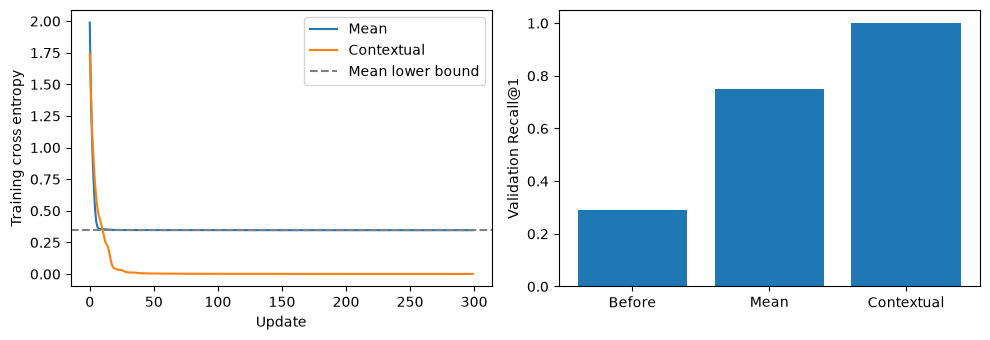

In [56]:
mean_metrics, mean_rows = evaluate_retrieval(mean_model, VALID)
retrieval_metrics, retrieval_rows = evaluate_retrieval(retriever, VALID)
show_table(["구조", "검증 Recall@1", "검증 Recall@3", "검증 MRR", "E의 변화량"], [
    ["평균", *(round(mean_metrics[k], 4) for k in ("Recall@1", "Recall@3", "MRR")),
     round(mean_table_change, 5)],
    ["문맥 encoder", *(round(retrieval_metrics[k], 4) for k in ("Recall@1", "Recall@3", "MRR")),
     round(retrieval_table_change, 5)],
])
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(mean_history, label="Mean")
axes[0].plot(retrieval_history, label="Contextual")
axes[0].axhline(0.5 * math.log(2), color="gray", linestyle="--", label="Mean lower bound")
axes[0].set(xlabel="Update", ylabel="Training cross entropy")
axes[0].legend()
axes[1].bar(["Before", "Mean", "Contextual"],
            [initial_metrics["Recall@1"], mean_metrics["Recall@1"], retrieval_metrics["Recall@1"]])
axes[1].set(ylim=(0, 1.05), ylabel="Validation Recall@1")
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "retrieval_training.svg")
fig.savefig(ARTIFACT_DIR / "retrieval_training.png", dpi=160)
plt.show()

### 5.6 평균 모델의 loss가 멈추는 이유를 계산한다

앞의 여섯 문서는 세 개의 역할 역전 쌍이다. 같은 쌍의 두 문서는 평균 모델에서 항상 같은 벡터이므로 어떤 질의에도 같은 점수를 받는다. 둘 중 하나가 정답일 때 그 정답의 softmax 확률은 최대 1/2다. 따라서 그 질의의 loss는 최소 $-\log(1/2)=\log2$다.

이런 질의가 전체 학습 질의의 절반이다. 나머지 절반의 loss를 0까지 줄일 수 있다고 가정해도 전체 평균 loss는 $0.5\log2\approx0.34657$보다 작아질 수 없다. 실제 cosine 점수의 범위와 유한한 temperature 때문에 정확히 그 값에 도달하지는 않을 수 있다.

동일한 이유로 균형 검증 질의에서 평균 모델의 Recall@1 상한은 75%다. 앞 절의 코드가 잘 실행됐는지 볼 때, 평균 모델이 이 한계를 넘지 못한다는 사실은 optimizer를 더 오래 돌려야 한다는 증거가 아니다.

In [57]:
show_table(["평균 모델", "값"], [
    ["구조에서 나온 loss 하한", round(0.5 * math.log(2), 6)],
    ["관측한 마지막 training loss", round(mean_history[-1], 6)],
    ["검증 Recall@1 상한", 0.75],
    ["관측한 검증 Recall@1", mean_metrics["Recall@1"]],
])
assert mean_metrics["Recall@1"] <= 0.75 + 1e-6
assert mean_history[-1] >= 0.5 * math.log(2) - 1e-5

평균 모델,값
구조에서 나온 loss 하한,0.346574
관측한 마지막 training loss,0.34688
검증 Recall@1 상한,0.75
관측한 검증 Recall@1,0.75


### 5.7 negative와 정답 집합을 바꾸면 loss도 바뀐다

지금은 모든 문서를 후보로 넣을 수 있지만 실제 corpus는 훨씬 크다. 다른 질의의 정답 문서를 같은 배치의 negative로 재사용하는 in-batch negative는 계산을 줄이는 한 방법이다. 배치의 각 질의가 서로 다른 정답 문서를 가진다면 B×B 점수 행렬의 대각선을 정답으로 둘 수 있다. 그러나 지금처럼 같은 정답을 가진 질의들이 있으면 단순 대각선 CE가 그 문서를 다른 행에서 오답으로 밀어낸다. 이때는 문서 ID로 중복을 없애거나, 같은 정답을 모두 positive로 표시해야 한다.

hard negative는 모델이 높은 점수를 주지만 실제로는 관련 없는 문서다. 단어가 겹치는 역관계 문서는 이 수업에서 그런 역할을 한다. 그러나 ‘같은 주제이므로 hard negative’라고 정하면 실제 정답을 오답으로 학습시키는 false negative가 생길 수 있다.

온톨로지의 상위 타입을 묻는 질의에는 여러 하위 개념 문서가 정답일 수 있다. `포유류의 예`에 고래 문서와 개 문서를 모두 정답으로 지정한다면 정답 집합 $P(q)$를 사용한다. 정답 집합의 전체 확률을 높이는 한 가지 목적은

$$L=-\log\frac{\sum_{j\in P(q)}\exp(s_j/\tau)}{\sum_j\exp(s_j/\tau)}$$

이다. 이 목적은 정답 하나에 높은 확률을 집중시켜도 작아질 수 있다. 모든 정답을 고르게 상위로 올려야 한다면 positive별 loss 평균 등의 다른 목적을 검토해야 한다. 아래 계산은 그 차이를 드러내는 작은 예다.

In [58]:
def positive_set_loss(logits, positive_mask):
    if positive_mask.shape != logits.shape or not positive_mask.any(dim=1).all():
        raise ValueError("각 질의에 적어도 하나의 positive가 필요합니다.")
    positive_logits = logits.masked_fill(~positive_mask, float("-inf"))
    return (torch.logsumexp(logits, dim=1) - torch.logsumexp(positive_logits, dim=1)).mean()

set_logits = torch.tensor([[5., 0., -2.]], requires_grad=True)
set_mask = torch.tensor([[True, True, False]])
set_loss = positive_set_loss(set_logits, set_mask)
set_loss.backward()
print("두 문서가 정답인 집합 loss:", round(set_loss.item(), 6))
print("softmax 확률:", set_logits.detach().softmax(-1).tolist())
print("각 logit의 gradient:", set_logits.grad.tolist())

두 문서가 정답인 집합 loss: 0.000906
softmax 확률: [[0.992408275604248, 0.006686794571578503, 0.0009049592190422118]]
각 logit의 gradient: [[-0.0008990168571472168, -6.05778768658638e-06, 0.0009049591026268899]]


두 번째 문서도 정답인데 확률은 첫 번째보다 훨씬 작다. 이 상황에서 loss가 작다는 것은 식이 요구한 일을 하고 있다는 뜻이며, 모든 정답을 균등하게 찾았다는 뜻은 아니다. label의 의미와 loss의 최적점이 맞는지 먼저 따져야 한다.

## 6. 검색을 실행하고 실패 원인을 나누어 보기

훈련 loss 하나로 모델의 동작을 다 설명할 수는 없다. 이제 같은 모델에서 위치를 제거하거나 토큰 테이블을 동결해 보면서 무엇이 필요한지 확인한다. 이어서 문서 벡터를 미리 계산하고, tokenizer·모델·문서 순서를 한 묶음으로 저장해 새 인스턴스에서 검색을 복원한다.

### 6.1 위치가 없는 attention은 순서 차이를 보존하는가

위치 표현이 없는 self-attention은 입력 토큰을 순열로 바꾸면 출력도 같은 순열로 바뀌는 성질을 가진다. 이를 permutation equivariance라고 한다. 그 출력에 순열 불변인 평균을 적용하면 결과는 같아진다. 이 교재의 segment ID는 전부 0이므로 별도의 순서 정보도 없다.

학습된 모델의 위치 벡터를 사용하지 않도록 바꿔 이 구조적 성질을 확인한다. 이것은 위치 없이 새로 학습한 모델과의 성능 비교는 아니다. 그 실험을 하려면 위치 없는 encoder를 새로 만들고 동일한 학습 조건으로 다시 학습해야 한다.

In [59]:
no_position_model = copy.deepcopy(retriever).eval()
no_position_model.use_positions = False
order_diagnostics = []
with torch.no_grad():
    for left, right in ORDER_PAIRS:
        texts = [DOCS[left], DOCS[right]]
        normal_vectors = encode_texts(retriever, texts)
        no_position_vectors = encode_texts(no_position_model, texts)
        average_vectors = encode_texts(mean_model, texts)
        no_position_gap = float((no_position_vectors[0] - no_position_vectors[1]).norm())
        order_diagnostics.append([
            f"{left} / {right}", float((normal_vectors[0] - normal_vectors[1]).norm()),
            no_position_gap, float((average_vectors[0] - average_vectors[1]).norm()),
        ])
        torch.testing.assert_close(no_position_vectors[0], no_position_vectors[1], atol=2e-5, rtol=2e-5)
show_table(["문서 쌍", "학습된 문맥 모델 거리", "위치 제거 후 거리", "평균 모델 거리"], order_diagnostics)

문서 쌍,학습된 문맥 모델 거리,위치 제거 후 거리,평균 모델 거리
0 / 1,1.3215012550354004,1.1003803734865869e-07,0.0
2 / 3,1.386762261390686,1.7255374018532166e-07,0.0
4 / 5,1.3197317123413086,1.1504001662387964e-07,0.0


벡터가 같거나 다른 것과 정답 문서가 1위가 되는 것도 별개다. 다른 벡터를 만들 수 있는 구조를 갖춘 뒤에는, 올바른 질의를 올바른 문서 쪽으로 배치하는 감독 신호가 필요하다. 위 표는 그중 표현 구조의 조건을 검사한다.

### 6.2 토큰 테이블을 고정하고 나머지만 학습한다

MLM 직후의 같은 초기 모델로 돌아가 E만 동결한다. 위치 표현, attention, FFN, projection은 계속 학습한다. 이 모델이 어느 정도 학습된다면 의미를 저장하는 장소를 E의 각 행 하나로만 설명할 수 없다는 것을 보여 준다. 그렇다고 토큰 임베딩 학습이 일반적으로 불필요하다는 결론이 나오지는 않는다.

In [60]:
frozen_retriever = copy.deepcopy(initial_retriever)
frozen_history, frozen_table_change = train_retriever(
    frozen_retriever, retrieval_training, freeze_tokens=True
)
frozen_metrics, _ = evaluate_retrieval(frozen_retriever, VALID)
assert frozen_table_change == 0
show_table(["학습할 파라미터", "검증 Recall@1", "검증 MRR", "E 변화량"], [
    ["전체", retrieval_metrics["Recall@1"], retrieval_metrics["MRR"], retrieval_table_change],
    ["E를 제외한 나머지", frozen_metrics["Recall@1"], frozen_metrics["MRR"], frozen_table_change],
])

학습할 파라미터,검증 Recall@1,검증 MRR,E 변화량
전체,1.0,1.0,2.7709884643554688
E를 제외한 나머지,0.9583333134651184,0.9791666865348816,0.0


지금 비교는 한 seed와 작은 데이터에 대한 관찰이다. 차이가 작아 보이면 실행 실수부터 확인하고, 다른 seed와 다른 데이터에서 반복해야 한다. 결과를 보고 architecture나 hyperparameter를 선택하면 그 검증 집합은 선택 과정에 참여한다.

### 6.3 학습된 모델에 padding을 더해도 검색 벡터가 같은지 검사한다

앞 장에서는 초기 encoder를 검사했다. 학습된 모델에도 같은 규칙이 유지되는지 확인한다. 단일 문장을 뒤에 PAD 5개가 붙은 문장과 비교한다. 내용과 원래 위치는 그대로다.

In [61]:
padding_batch = pack_batch([DOCS[0]])
longer_batch = {
    "input_ids": F.pad(padding_batch["input_ids"], (0, 5), value=tokenizer.pad_id),
    "attention_mask": F.pad(padding_batch["attention_mask"], (0, 5), value=False),
    "pool_mask": F.pad(padding_batch["pool_mask"], (0, 5), value=False),
    "token_type_ids": F.pad(padding_batch["token_type_ids"], (0, 5), value=0),
}
with torch.no_grad():
    ordinary_vector = retriever(padding_batch)
    padded_vector = retriever(longer_batch)
torch.testing.assert_close(ordinary_vector, padded_vector, atol=2e-5, rtol=2e-5)
padding_error = float((ordinary_vector - padded_vector).abs().max())
print("padding 추가 후 좌표별 최대 차이:", padding_error)

padding 추가 후 좌표별 최대 차이: 4.470348358154297e-08


문제의 원인을 찾을 때 이처럼 불변이어야 하는 값을 정해 두면 편하다. 질의 자체가 바뀌었는데 결과가 변하는 것은 자연스럽지만, PAD만 추가했는데 순위가 크게 바뀐다면 attention mask나 pooling을 먼저 검사해야 한다.

### 6.4 문서 벡터를 미리 계산해서 검색한다

학습이 끝났으므로 문서 벡터를 한 번만 계산한다. 질의가 들어오면 질의 하나를 인코딩하고 저장된 행렬과 곱한다. 아래 구현은 모든 문서를 정확히 비교하는 exact search다. 현재 12개 문서에는 이것으로 충분하다.

In [62]:
retriever.eval()
with torch.no_grad():
    document_index = encode_texts(retriever, DOCS).detach().clone()
assert document_index.shape == (len(DOCS), 32)
torch.testing.assert_close(document_index.norm(dim=1), torch.ones(len(DOCS)), atol=1e-6, rtol=1e-5)

@torch.no_grad()
def search_documents(query, model, tokenizer, document_vectors, documents, names, top_k=3):
    if not 1 <= top_k <= len(documents):
        raise ValueError("top_k는 1 이상 문서 수 이하여야 합니다.")
    if document_vectors.shape[0] != len(documents) or len(names) != len(documents):
        raise ValueError("벡터의 행 순서와 문서 목록이 맞아야 합니다.")
    model.eval()
    batch = pack_batch([query], tokenizer=tokenizer, max_len=model.max_len)
    query_vector = model(batch)
    scores = (query_vector @ document_vectors.T)[0]
    if not torch.isfinite(scores).all():
        raise FloatingPointError("검색 점수에 NaN 또는 무한대가 있습니다.")
    ranking = scores.argsort(descending=True, stable=True)[:top_k].tolist()
    content_ids = batch["input_ids"][batch["pool_mask"]]
    unknown_count = int((content_ids == tokenizer.unk_id).sum())
    rows = [{"id": index, "score": float(scores[index]), "name": names[index], "text": documents[index]}
            for index in ranking]
    return rows, {"unknown_tokens": unknown_count, "content_tokens": len(content_ids)}

my_query = "쥐 가 고양이 를 뒤쫓다 장면"
hits, input_info = search_documents(my_query, retriever, tokenizer, document_index, DOCS, DOC_NAMES)
print("질의:", my_query, "/ 토큰 정보:", input_info)
show_table(["순위", "문서 ID", "cosine", "문서"],
           [[rank, hit["id"], round(hit["score"], 5), hit["text"]] for rank, hit in enumerate(hits, 1)])

질의: 쥐 가 고양이 를 뒤쫓다 장면 / 토큰 정보: {'unknown_tokens': 0, 'content_tokens': 6}


순위,문서 ID,cosine,문서
1,1,0.99872,쥐 가 고양이 를 쫓다
2,7,0.13312,환불 처리 이후 입금 소요 기간
3,0,0.10822,고양이 가 쥐 를 쫓다


위 셀의 `my_query`만 바꾸면 자신의 질의를 넣을 수 있다. 이 BPE는 어절을 문자로 분해할 수 있으므로, 학습 때 없었던 단어도 이미 배운 문자들의 조합이면 표현할 수 있다. 그래도 새로운 표현의 의미를 배웠다는 보장은 없다. 학습된 문자만으로 표현 가능한 새로운 단어와, `[UNK]`가 생기는 새로운 문자를 분리해서 봐야 한다.

In [63]:
oov_rows = []
for query in ["고양이쥐", "패스워드 리커버리", "고양이 🧬"]:
    oov_hits, info = search_documents(query, retriever, tokenizer, document_index, DOCS, DOC_NAMES)
    oov_rows.append([query, info["unknown_tokens"], info["content_tokens"],
                     oov_hits[0]["name"], round(oov_hits[0]["score"], 4)])
show_table(["입력", "UNK 수", "내용 토큰 수", "반환된 1위", "점수"], oov_rows)

입력,UNK 수,내용 토큰 수,반환된 1위,점수
고양이쥐,0,2,반려묘 먹이 선택,0.8876
패스워드 리커버리,3,10,카드 결제 실패,0.4763
고양이 🧬,1,3,진료 예약 취소,0.6054


모르는 입력에도 1위는 나온다. 검색기는 후보를 정렬했을 뿐, 정답이 존재한다고 판정하지 않았다. 실제 제품에서는 정답 없는 질의도 포함한 검증 자료로 응답 보류나 threshold를 설계해야 한다. 이 작은 자료의 점수를 보고 모든 서비스에 쓸 threshold 하나를 정할 수는 없다.

### 6.5 저장할 단위는 가중치 파일 하나보다 크다

동일한 가중치라도 토크나이저 ID가 바뀌면 다른 함수를 계산한다. 문서 벡터의 행 순서와 문서 목록이 바뀌면 점수는 맞아도 엉뚱한 문서를 돌려준다. 모델을 갱신하고 기존 문서 벡터를 계속 써도 질의와 문서가 서로 다른 공간에 놓일 수 있다.

따라서 이 실습은 tokenizer의 정규화·merge·ID 순서, 모델 구조와 가중치, pooling 설정, 문서 목록과 벡터를 한 묶음으로 저장한다. optimizer 상태는 저장하지 않는다. 아래 파일은 추론을 재현하는 checkpoint이며, 학습을 정확히 이어서 재개하는 checkpoint는 아니다. 학습 재개에는 optimizer와 RNG 상태, 데이터 진행 위치도 필요하다.

In [64]:
bundle = {
    "format_version": 1,
    "tokenizer": tokenizer.to_dict(),
    "encoder_config": asdict(encoder_config),
    "retriever_config": {"output_dim": retriever.output_dim,
                         "pooling": retriever.pooling, "use_positions": retriever.use_positions},
    "state_dict": retriever.state_dict(),
    "documents": list(DOCS),
    "document_names": list(DOC_NAMES),
    "document_vectors": document_index,
}
bundle_path = ARTIFACT_DIR / "retriever.pt"
torch.save(bundle, bundle_path)

loaded = torch.load(bundle_path, map_location="cpu", weights_only=True)
if loaded["format_version"] != 1:
    raise ValueError("지원하지 않는 checkpoint 버전입니다.")
loaded_tokenizer = ScratchBPE.from_dict(loaded["tokenizer"])
loaded_config = ModelConfig(**loaded["encoder_config"])
assert loaded_config.vocab_size == loaded_tokenizer.vocab_size
loaded_model = SentenceEncoder(TinyBert(loaded_config), **loaded["retriever_config"])
loaded_model.load_state_dict(loaded["state_dict"])
loaded_model.eval()
loaded_documents = loaded["documents"]
loaded_names = loaded["document_names"]
loaded_index = loaded["document_vectors"]

with torch.no_grad():
    recomputed_index = encode_texts(loaded_model, loaded_documents, loaded_tokenizer)
torch.testing.assert_close(recomputed_index, loaded_index, atol=0, rtol=0)
loaded_hits, _ = search_documents(my_query, loaded_model, loaded_tokenizer,
                                   loaded_index, loaded_documents, loaded_names)
assert [hit["id"] for hit in loaded_hits] == [hit["id"] for hit in hits]
print("새 인스턴스에서 벡터와 검색 순위 복원:", bundle_path.name)

새 인스턴스에서 벡터와 검색 순위 복원: retriever.pt


여기서는 같은 CPU 환경에서 같은 계산을 수행하므로 완전 일치를 검사했다. 다른 장치나 수치 정밀도로 옮길 때에는 허용 오차와 순위 안정성을 따로 확인해야 한다. 위 저장 파일에서 가중치만 바꾸고 벡터는 그대로 두는 식의 수동 변경은 하지 않는다.

### 6.6 별도로 보관한 질의의 결과를 확인한다

토크나이저, MLM, 검색 학습은 모두 끝났다. 이제 처음 분리한 `TEST` 질의를 평가한다. 이 집합 역시 같은 문서와 유사한 표현을 공유하는 합성 자료다. 별도 문자열이라는 조건은 지키지만, 새로운 언어·도메인·entity에 대한 성능 증거로 확대할 수는 없다.

In [65]:
test_metrics, test_rows = evaluate_retrieval(retriever, TEST)
test_mean_metrics, _ = evaluate_retrieval(mean_model, TEST)
show_table(["구조", "TEST Recall@1", "TEST Recall@3", "TEST MRR"], [
    ["평균", *(round(test_mean_metrics[k], 4) for k in ("Recall@1", "Recall@3", "MRR"))],
    ["문맥 encoder", *(round(test_metrics[k], 4) for k in ("Recall@1", "Recall@3", "MRR"))],
])
errors = [row for row in test_rows if row["rank"] != 1]
show_table(["질의", "정답", "정답 순위", "상위 3개"], [
    [row["query"], DOC_NAMES[row["target"]], row["rank"],
     ", ".join(DOC_NAMES[i] for i in row["top3"])] for row in errors
])
print("1위 오류 질의 수:", len(errors), "/", len(TEST))

구조,TEST Recall@1,TEST Recall@3,TEST MRR
평균,0.75,1.0,0.875
문맥 encoder,1.0,1.0,1.0


질의,정답,정답 순위,상위 3개


1위 오류 질의 수: 0 / 24


오류가 없다면 문제를 더 잘 설계해야 한다. 모든 학습 질의와 비슷한 템플릿만 평가하면 모델이 문장 구조를 일반화했는지, 단순히 반복되는 조합을 외웠는지 구별하기 어렵다. 다음 장의 과제는 새로운 entity와 관계 조합을 분리해 이 한계를 드러내는 것이다. 반대로 오류가 있다면 학습 epoch를 늘리기 전에 토큰화, 정답의 모호성, 순서를 잃은 표현, 실제 문맥 추론 실패 중 어디에 속하는지 분류한다.

In [66]:
course_report = {
    "python": sys.version.split()[0], "torch": torch.__version__,
    "seeds": {"global": SEED, "mlm_initialization": 41, "mlm_corruption": 45,
              "mlm_diagnostic": 44, "retrieval_projection": 17},
    "vocabulary_size": tokenizer.vocab_size, "bpe_merges": len(tokenizer.merges),
    "encoder_config": asdict(encoder_config), "retrieval_training": asdict(retrieval_training),
    "data": {"documents": len(DOCS), "train": len(TRAIN), "validation": len(VALID), "test": len(TEST)},
    "mlm_diagnostic_before": mlm_before, "mlm_diagnostic_after": mlm_after,
    "retrieval_validation_before": initial_metrics,
    "retrieval_validation_after": retrieval_metrics, "mean_validation_after": mean_metrics,
    "frozen_validation_after": frozen_metrics,
    "retrieval_test": test_metrics, "mean_test": test_mean_metrics,
    "embedding_gradient": {"autograd": autograd_gradient, "finite_difference": numeric_gradient},
    "padding_error": padding_error, "frozen_table_change": frozen_table_change,
    "order_diagnostics": order_diagnostics,
    "test_predictions": test_rows,
    "elapsed_seconds": time.perf_counter() - STARTED_AT,
    "evaluation_scope": "Synthetic queries against a known corpus; not a natural-language benchmark.",
}
(ARTIFACT_DIR / "results.json").write_text(json.dumps(course_report, ensure_ascii=False, indent=2), encoding="utf-8")
print("실행 결과 저장:", Path("artifacts/course/results.json"))
print("여기까지의 실행 시간:", round(course_report["elapsed_seconds"], 2), "초")

실행 결과 저장: artifacts/course/results.json
여기까지의 실행 시간: 8.26 초


## 7. 코드를 바꾸는 연습

완성 코드를 실행하는 동안에는 구현의 선택을 그대로 따라갔다. 이제 작은 요구사항을 바꾸어 직접 작성해 보자. 각 문제는 앞의 모델을 지우지 않고 별도 함수로 실험할 수 있다. 먼저 문제만 읽고 빈 셀에 구현한 뒤, 아래의 해설 코드와 비교한다. 해설 셀도 실행되므로 전체 노트북을 처음부터 실행하는 데는 막히는 곳이 없다.

### 7.1 lookup의 backward를 직접 계산하기

**문제.** 토큰 ID가 `[2, 4, 2, 0]`이고 각 조회 위치에서 도착한 gradient가 `[T,D]`로 주어진다. 임베딩 행렬의 gradient `[V,D]`를 반환하는 함수를 작성하라. 같은 ID는 합산하고 PAD 행은 제외한다. 이 함수에서 autograd를 호출하지 않는다.

한 위치의 gradient를 테이블의 해당 행으로 보내면 된다. 같은 행이 반복될 수 있으므로 대입이 아니라 더하기다. `scatter`나 `index_add`를 쓰는 구현도 가능하지만, 먼저 반복문으로 작성하면 어떤 값을 어디에 더하는지 확인하기 쉽다.

In [67]:
def lookup_backward(ids, incoming_gradient, vocabulary_size, padding_id=0):
    if ids.ndim != 1 or incoming_gradient.shape[0] != ids.numel():
        raise ValueError("ids는 [T], incoming_gradient는 [T,D]여야 합니다.")
    table_gradient = incoming_gradient.new_zeros(vocabulary_size, incoming_gradient.shape[-1])
    for position, token_id in enumerate(ids.tolist()):
        if token_id != padding_id:
            table_gradient[token_id] += incoming_gradient[position]
    return table_gradient

exercise_ids = torch.tensor([2, 4, 2, 0])
incoming = torch.tensor([[1., 2.], [3., 4.], [-1., 5.], [9., 9.]])
hand_gradient = lookup_backward(exercise_ids, incoming, vocabulary_size=6)
assert torch.equal(hand_gradient[2], torch.tensor([0., 7.]))
assert torch.equal(hand_gradient[4], torch.tensor([3., 4.]))
assert torch.equal(hand_gradient[0], torch.zeros(2))
print(hand_gradient)

tensor([[0., 0.],
        [0., 0.],
        [0., 7.],
        [0., 0.],
        [3., 4.],
        [0., 0.]])


ID 2는 두 번 등장했지만 첫 좌표는 $1+(-1)=0$이다. 등장 횟수와 gradient norm이 비례하지 않는 이유를 숫자로 볼 수 있다. 저장 공간을 아끼기 위해 sparse gradient를 쓰는 구현도 있지만, 현재 모델은 작은 테이블이므로 dense gradient로 충분하다.

### 7.2 max pooling을 구현하기

**문제.** 내용 토큰들의 각 좌표별 최댓값을 반환하는 `masked_max(hidden, mask)`를 작성하라. PAD를 0으로 바꾸고 최댓값을 구하면 음수만 있는 좌표에서 오류가 난다. 그 반례를 먼저 만들고 고쳐 보라.

In [68]:
def masked_max(hidden, pool_mask):
    if not pool_mask.any(dim=1).all():
        raise ValueError("내용 토큰이 없는 문장을 max pooling할 수 없습니다.")
    masked = hidden.masked_fill(~pool_mask.unsqueeze(-1), float("-inf"))
    return masked.max(dim=1).values

negative_states = torch.tensor([[[-3., -2.], [-1., -4.], [100., 100.]]])
negative_mask = torch.tensor([[True, True, False]])
bad_max = (negative_states * negative_mask.unsqueeze(-1)).max(dim=1).values
good_max = masked_max(negative_states, negative_mask)
print("PAD를 0으로 덮은 잘못된 결과:", bad_max)
print("PAD를 후보에서 제외한 결과:", good_max)
torch.testing.assert_close(good_max, torch.tensor([[-1., -2.]]))

PAD를 0으로 덮은 잘못된 결과: tensor([[0., 0.]])
PAD를 후보에서 제외한 결과: tensor([[-1., -2.]])


`SentenceEncoder.forward`의 pooling 부분을 이 함수로 바꿀 수 있다. 이미 학습된 mean 모델의 pooling만 바꿔 본 결과는 추론 규칙 변경 실험이다. max pooling으로 학습한 모델과 비교하려면 같은 초기 encoder에서 새 projection과 optimizer로 다시 학습해야 한다. 두 실험의 질문을 섞지 않는다.

### 7.3 모든 positive를 학습시키는 목적함수

**문제.** 5장의 집합 확률 loss 대신, positive마다 negative log probability를 계산하고 평균하는 함수를 작성하라. 각 질의의 positive 수가 달라도 질의마다 같은 비중을 주어야 한다. positive가 하나라면 일반 CE와 같아야 한다.

$$L_i=-\frac{1}{|P_i|}\sum_{j\in P_i}\log p_{ij},\qquad L=\frac1B\sum_i L_i.$$

In [69]:
def average_positive_loss(logits, positive_mask):
    counts = positive_mask.sum(dim=1)
    if logits.shape != positive_mask.shape or (counts == 0).any():
        raise ValueError("각 질의에 하나 이상의 positive가 필요합니다.")
    log_prob = logits.log_softmax(dim=-1)
    chosen_log_prob = log_prob.masked_fill(~positive_mask, 0)
    per_query_loss = -chosen_log_prob.sum(dim=1) / counts
    return per_query_loss.mean()

multi_logits = torch.tensor([[5., 0., -2.]], requires_grad=True)
multi_mask = torch.tensor([[True, True, False]])
uniform_positive_loss = average_positive_loss(multi_logits, multi_mask)
uniform_gradient, = torch.autograd.grad(uniform_positive_loss, multi_logits)
singleton_mask = torch.tensor([[True, False, False]])
torch.testing.assert_close(average_positive_loss(multi_logits, singleton_mask),
                           F.cross_entropy(multi_logits, torch.tensor([0])))
print("positive별 평균 loss:", float(uniform_positive_loss.detach()))
print("logit gradient:", uniform_gradient.tolist())

positive별 평균 loss: 2.5076208114624023
logit gradient: [[0.49240827560424805, -0.493313193321228, 0.0009049591026268899]]


positive가 두 개일 때 이 목적은 두 정답의 확률이 균형을 이루는 방향도 요구한다. 현재 첫 정답에 확률이 지나치게 몰려 있으면 첫 점수를 낮추는 gradient가 나올 수 있다. ‘정답 점수는 항상 올라야 한다’는 규칙을 기계적으로 적용하면 이런 목적을 이해하기 어렵다. 원하는 검색 행동이 무엇인지부터 정하고 식을 읽어야 한다.

한 질의에서 logit에 대한 미분은 $p_j-\mathbf{1}[j\in P]/|P|$이다. 정답이 두 개라면 각 정답에 1/2씩 확률을 배분하고 나머지에는 0을 주는 것이 최적이다. 그때 loss의 하한은 0이 아니라 $\log2$이다. 일반적으로 이 loss는 positive에 균등한 정답 분포 y의 entropy와 $\mathrm{KL}(y\Vert p)$의 합이므로, 하한은 $\log|P|$이다. 서로 다른 positive 수나 목적함수의 loss를 절대값만으로 비교하면 안 된다.

### 7.4 길이 제한을 넘는 문서를 chunk로 나누기

**문제.** encoder의 `max_len=96`에는 `[CLS]`, `[SEP]`도 포함된다. 원문을 BPE ID로 바꾼 뒤 내용 토큰을 최대 94개씩 자르고, 인접 chunk가 일부 토큰을 공유하게 하라. 각 chunk가 원문의 어느 ID 구간에서 왔는지도 남겨야 한다.

아래 구현은 토큰 수준의 chunking이다. 문장 경계를 보존하지 않으며, subword 중간에서 끊길 수 있다. 긴 글의 문단 구조가 중요하다면 문장·문단 경계와 길이 제한을 함께 사용해야 한다. 문서 정답 label을 chunk 정답으로 옮길 때에도 모든 chunk가 답을 담고 있다고 가정하면 안 된다.

In [70]:
def make_token_chunks(text, tokenizer, max_content_tokens=94, overlap=16):
    if max_content_tokens < 1 or not 0 <= overlap < max_content_tokens:
        raise ValueError("0 <= overlap < max_content_tokens여야 합니다.")
    content_ids = tokenizer.encode(text, add_special_tokens=False)
    stride = max_content_tokens - overlap
    chunks = []
    start = 0
    while start < len(content_ids):
        end = min(start + max_content_tokens, len(content_ids))
        chunks.append({"start": start, "end": end,
                       "ids": [tokenizer.cls_id, *content_ids[start:end], tokenizer.sep_id]})
        if end == len(content_ids):
            break
        start += stride
    return chunks

def pack_chunks(chunks, tokenizer):
    width = max(len(chunk["ids"]) for chunk in chunks)
    ids = torch.full((len(chunks), width), tokenizer.pad_id, dtype=torch.long)
    attention = torch.zeros_like(ids, dtype=torch.bool)
    pool = torch.zeros_like(ids, dtype=torch.bool)
    for row, chunk in enumerate(chunks):
        length = len(chunk["ids"])
        ids[row, :length] = torch.tensor(chunk["ids"])
        attention[row, :length] = True
        pool[row, 1:length - 1] = True
    return {"input_ids": ids, "attention_mask": attention,
            "pool_mask": pool, "token_type_ids": torch.zeros_like(ids)}

long_text = " ".join([DOCS[6], DOCS[8], DOCS[9]] * 8)
chunks = make_token_chunks(long_text, loaded_tokenizer, max_content_tokens=loaded_config.max_len - 2)
chunk_batch = pack_chunks(chunks, loaded_tokenizer)
assert chunk_batch["input_ids"].shape[1] <= loaded_config.max_len
with torch.no_grad():
    chunk_vectors = loaded_model(chunk_batch)
show_table(["chunk", "내용 ID 시작", "내용 ID 끝(미포함)", "special 포함 길이"],
           [[i, c["start"], c["end"], len(c["ids"])] for i, c in enumerate(chunks)])
print("chunk 벡터:", tuple(chunk_vectors.shape))
original_long_ids = loaded_tokenizer.encode(long_text, add_special_tokens=False)
covered = set()
for chunk in chunks:
    assert chunk["ids"][1:-1] == original_long_ids[chunk["start"]:chunk["end"]]
    covered.update(range(chunk["start"], chunk["end"]))
assert covered == set(range(len(original_long_ids)))

chunk,내용 ID 시작,내용 ID 끝(미포함),special 포함 길이
0,0,94,96
1,78,172,96
2,156,248,94


chunk 벡터: (3, 32)


chunk 벡터를 검색해서 반환할 때에는 `(원문 문서 ID, 시작 위치, 끝 위치)`를 함께 보관한다. 여러 chunk가 같은 원문에서 나왔을 때 문서 하나로 합칠지, 답이 포함된 부분을 그대로 보여 줄지도 제품의 요구에 따라 결정한다. 이 예에서 위치는 문자 offset이 아니라 **BPE ID의 offset**이다. 원문을 정확히 하이라이트하려면 tokenizer 단계부터 문자 offset을 추적해야 한다.

### 7.5 다중 정답과 관련성 등급을 평가하기

**문제.** 문서의 관련성 등급이 0, 1, 2처럼 주어질 때 nDCG@k를 계산하라. 이 실습에서는 gain을 $2^{rel}-1$, 순위 discount를 $\log_2(r+1)$로 정한다. DCG를 가능한 이상적 순서의 DCG로 나눈 것이 nDCG다. 어떤 gain을 썼는지 명시해야 지표 숫자를 비교할 수 있다.

In [71]:
def ndcg_at_k(ranking, relevance, k):
    if not isinstance(k, int) or k < 1:
        raise ValueError("k는 양의 정수여야 합니다.")
    if len(ranking) != len(set(ranking)):
        raise ValueError("ranking에는 중복 문서가 없어야 합니다. chunk를 문서로 합칠 때 먼저 중복을 처리하세요.")
    if any(grade < 0 for grade in relevance.values()):
        raise ValueError("이 gain 정의에서는 관련성 등급이 0 이상이어야 합니다.")
    def dcg(grades):
        return sum((2 ** grade - 1) / math.log2(rank + 2)
                   for rank, grade in enumerate(grades))
    actual = [relevance.get(document_id, 0) for document_id in ranking[:k]]
    ideal = sorted(relevance.values(), reverse=True)[:k]
    ideal_score = dcg(ideal)
    return dcg(actual) / ideal_score if ideal_score else 0.0

grades = {"A": 2, "B": 1, "C": 0}
assert ndcg_at_k(["A", "B", "C"], grades, 3) == 1.0
assert 0 < ndcg_at_k(["B", "A", "C"], grades, 3) < 1
assert ndcg_at_k(["X"], {}, 1) == 0.0
try:
    ndcg_at_k(["A", "A"], grades, 2)
except ValueError:
    pass
else:
    raise AssertionError("중복 문서는 nDCG가 1을 넘도록 만들 수 있으므로 거부해야 합니다.")
print("이상적 순위의 nDCG:", ndcg_at_k(["A", "B", "C"], grades, 3))
print("정답은 같지만 순서가 바뀐 nDCG:", ndcg_at_k(["B", "A", "C"], grades, 3))

이상적 순위의 nDCG: 1.0
정답은 같지만 순서가 바뀐 nDCG: 0.7967075809905066


관련성 판정이 없는 문서를 코드에서는 0으로 처리했다. 실제 평가 자료에서는 미판정 문서가 곧 무관한 문서라는 뜻은 아니다. 검색기가 새로 찾아낸 좋은 문서가 label에 없으면 점수가 낮아질 수 있다. 결과를 읽을 때 판정 자료의 범위도 확인해야 한다.

### 7.6 온톨로지로 더 어려운 평가 자료를 설계하기

**문제.** 현재 자료는 같은 entity를 여러 표현으로 반복한다. 새로운 entity와 관계 조합에도 학습한 규칙이 적용되는지 보려면 어떻게 나눌 것인가?

먼저 토크나이저가 그 entity를 표현할 수 있는지와, encoder가 새 조합을 처리하는지를 분리해야 한다. 토크나이저에서 전부 `[UNK]`로 바뀌었다면 이후 모델의 관계 추론을 검사한 것이 아니다. 다음 셀은 새 표현을 넣기 전에 입력 정보가 어디까지 보존되는지 조사하는 예다.

In [72]:
new_relation_texts = [
    "고양이 가 토끼 를 쫓다",
    "토끼 가 고양이 를 쫓다",
    "여우 가 사슴 를 쫓다",
]
show_table(["새 조합", "BPE 조각", "UNK 수"], [
    [text, " | ".join(tokenizer.pieces[i] for i in tokenizer.encode(text, add_special_tokens=False)),
     tokenizer.encode(text, add_special_tokens=False).count(tokenizer.unk_id)]
    for text in new_relation_texts
])

새 조합,BPE 조각,UNK 수
고양이 가 토끼 를 쫓다,▁고양이 | ▁가 | ▁토끼 | ▁를 | ▁쫓다,0
토끼 가 고양이 를 쫓다,▁토끼 | ▁가 | ▁고양이 | ▁를 | ▁쫓다,0
여우 가 사슴 를 쫓다,▁ | [UNK] | 우 | ▁가 | ▁ | 사 | [UNK] | ▁를 | ▁쫓다,2


새 실험에서는 먼저 train/validation/test의 entity 집합 또는 관계 조합을 정한다. 그 뒤 각 split 안에서만 문장을 만든다. 모든 문장을 만든 다음 무작위로 섞으면 거의 같은 template와 entity 조합이 여러 split에 들어가기 쉽다. 상위·하위 타입이나 동의 표현으로 positive를 늘릴 때도 ‘같은 개념’과 ‘이 질의에 답함’은 별도의 판정이다. `고양이 사료` 문서가 `고양이가 무엇을 쫓는가`의 정답은 아니다.

<details>
<summary>분할 설계의 한 가지 해설</summary>

세 평가를 따로 둔다. 첫째는 같은 entity와 관계에서 새 질의 표현을 평가한다. 둘째는 각 entity와 관계는 학습에 있지만 그 조합은 처음인 경우를 평가한다. 셋째는 entity 자체가 처음인 경우를 평가한다. tokenizer는 허용된 학습 corpus로만 학습하고 각 평가의 UNK 비율을 별도로 기록한다. 셋째 평가에 UNK가 많다면 tokenization 문제와 encoder 일반화 문제를 나누어 보고한다. 문서가 미리 알려진 실험과 문서 자체도 처음인 실험 역시 구분한다.

각 관계의 정방향과 역방향을 같은 split 안에 배치해 어려운 negative를 만든다. 단, 대칭 관계라면 역방향을 오답으로 만들지 않는다. 예를 들어 ‘형제 관계’를 방향이 있는 ‘가르치다’ 관계와 같은 방식으로 label하면 지식과 supervision이 충돌한다.

</details>

### 자주 막히는 지점

| 증상 | 먼저 확인할 것 | 이 교재에서 확인할 위치 |
|---|---|---|
| 토큰 ID가 embedding 범위를 벗어남 | 모델 생성 후 tokenizer를 다시 학습했는가 | 1장의 저장/복원, 2장의 config |
| 모든 loss가 NaN | 전부 PAD인 행, 전부 ignore인 label, 불안정한 exp, 너무 큰 update | 2장의 key mask, 3장의 선택 위치 검사 |
| padding 길이에 따라 결과가 크게 바뀜 | key mask와 pooling mask의 역할을 혼동했는가 | 6.3의 padding 불변성 |
| gradient가 계속 누적됨 | step 전에 zero_grad를 호출했는가 | 3.5와 5.5 |
| backward를 두 번 할 때 오류 | 소비한 그래프를 재사용했는가 | forward부터 재실행 |
| 학습 loss는 작지만 검색이 틀림 | 중복 정답을 negative로 뒀는가, label의 관련성이 타당한가 | 5.7 |
| eval인데 gradient가 만들어짐 | eval은 미분을 끄는 명령이 아님 | 2.1의 PyTorch 실행 규칙 |
| 저장 후 다른 문서가 반환됨 | tokenizer·모델·문서 벡터·행 ID가 같은 버전인가 | 6.5 |

### 여기서 규모를 늘릴 때

정확 검색은 N개 문서, d차원 벡터에 대해 질의당 대략 O(Nd)의 점수 계산을 한다. float32 벡터만 저장하면 대략 `4*N*d` byte가 필요하다. 백만 문서를 768차원으로 저장하면 벡터 값만 약 3.07 GB다. 이 수치는 원문과 인덱스의 부가 자료를 포함하지 않는다.

ANN 인덱스는 이 검색을 근사해서 계산량과 정확도의 교환관계를 만든다. 이때 ‘정확한 벡터 검색의 top-k를 얼마나 재현하는가’와 ‘실제 관련 문서를 얼마나 찾는가’는 다른 지표다. 좋은 ANN 설정도 잘못 학습된 임베딩의 관련성을 고쳐 주지는 않는다. 이후에 cross-encoder로 후보를 재정렬하면 토큰 간 상호작용을 더 계산할 수 있지만, 첫 검색에서 빠진 문서는 후보를 추가하지 않는 한 복구할 수 없다.

실제 데이터로 옮길 때에는 BM25 같은 어휘 검색도 같은 정답 자료에서 비교한다. 제품 번호, 숫자, 희귀 고유명사는 벡터 모델이 놓칠 수 있다. 어느 방법이 좋은지는 모델 이름보다 검색할 자료와 질문의 분포에 달려 있다. 작은 교육 자료에서 얻은 100%를 모델 선택의 근거로 사용하지 않는다.

### 스스로 다시 작성해 볼 순서

완성 코드를 닫고 다음 네 인터페이스를 빈 파일에 적는다. 각 함수의 입력과 출력 shape부터 적은 뒤 구현한다.

1. `encode(text) -> list[int]`: 정규화, BPE rank 적용, 특수 토큰, 미등록 문자 처리.
2. `encoder(input_ids, attention_mask) -> [B,T,D]`: lookup, 위치, QKV, mask, residual, FFN.
3. `sentence_encoder(batch) -> [B,d]`: 내용 mask의 평균, projection, 정규화.
4. `loss(queries, documents, targets) -> scalar`: 독립 인코딩, 점수 행렬, 후보 집합, CE.

그 뒤 한 토큰 행의 gradient를 수치 미분으로 확인하고, 역할을 뒤집은 문서 쌍을 만들고, 저장한 모델의 검색 결과를 복원한다. 이 네 함수와 세 검사를 자신의 코드로 작성하면, 이 노트북에서 사용한 구조의 계산과 학습을 직접 재구성한 것이다.

### 원전과 구현 문서

토크나이저의 BPE 학습은 [Sennrich et al., 2016](https://aclanthology.org/P16-1162/)에서 번역의 희귀어 문제와 함께 읽을 수 있다. 경계 표식과 Unicode 정규화는 이 교재가 선택한 구체적인 구현 규칙이다.

attention 계산과 차원별 scaling은 [Vaswani et al., 2017](https://arxiv.org/abs/1706.03762)의 3절에 설명되어 있다. BERT의 입력 표현과 MLM·NSP는 [Devlin et al., 2019](https://aclanthology.org/N19-1423/)의 3절을 참고한다. 이 교재는 그중 양방향 encoder와 MLM을 사용하며 원형 BERT 전체를 재현하지 않는다.

문장 벡터를 비교 가능하게 학습하는 문제는 [Sentence-BERT](https://aclanthology.org/D19-1410/)로, 질의와 문서의 독립 인코딩을 검색 supervision과 연결하는 문제는 [DPR](https://aclanthology.org/2020.emnlp-main.550/)로 이어진다. 코드와 라이브러리의 경계를 확인할 때에는 [Embedding](https://docs.pytorch.org/docs/stable/generated/torch.nn.Embedding.html)과 [CrossEntropyLoss](https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)의 파라미터 정의를 함께 읽는다.